# Clustering

Welcome to this notebook on clustering in chemoinformatics!  
Here, we will explore the concept of clustering, a technique used to group similar compounds together. This is a crucial step in chemoinformatics, aiding in the discovery of new drugs by identifying patterns and relationships in large datasets. 

More about different clustering methods and score to validate result: https://blog.dailydoseofds.com/p/intrinsic-measures-for-clustering, https://blog.dailydoseofds.com/p/how-to-evaluate-clustering-results,  https://www.um.edu.mt/library/oar/bitstream/123456789/52960/4/19MAIPT004.pdf, https://portal.valencelabs.com/datamol/post/clustering-molecules-6swnHE5va6LhuFp, https://www.frontiersin.org/journals/natural-products/articles/10.3389/fntpr.2024.1367537/full.

Clustering aims to group objects such that objects in a group are more similiar to each other than to those in other groups. It is usually an unsupervised method, identifying the differences between objects from the data itself.

We want to cluster ligands to identify groups/clusters within our data set. But first, let's import the necessary tools for the job:

In [36]:
#!pip install -U jupyterlab ipywidgets mols2grid umap-learn plotly plotly_express
#!conda install -y -c bokeh bokeh
#!conda install -y -c conda-forge scikit-learn

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bokeh.io import output_notebook
output_notebook()

from rdkit.Chem.Draw import IPythonConsole

from rdkit import Chem, DataStructs
from rdkit.Chem import PandasTools, rdFingerprintGenerator
from rdkit.ML.Cluster import Butina

from sklearn.decomposition import PCA

from tqdm.auto import tqdm

# Set RDKit to use SVG graphics in Jupyter Notebook (better quality images)
IPythonConsole.ipython_useSVG = True
PandasTools.RenderImagesInAllDataFrames(images=True)
PandasTools.molRepresentation='svg'

Loading BokehJS ...

Clustering [https://en.wikipedia.org/wiki/Cluster_analysis] related to unsupervised learning and can be defined as the task of grouping a set of objects in such a way that objects in the same group (called a cluster) are more similar (in some sense) to each other than to those in other groups (clusters). It identifies homogeneous subgroups within the data, making it easier to discern the underlying structure and relationships.

Clustering is based on similarity calculations among the elements to enable the grouping of the molecules together.

Similar compounds might bind to the same targets and show similar effects. Based on this similar property principle, compound similarity can be used to build dostinct chemical groups via clustering (groups of similar compounds). From such a clustering, a diverse set of compounds can also be selected from a larger set of screening compounds for further non-redundant experimental testing.

Molecular similarity provides a score representing the similarity between two molecules, with two identical molecules having a score of 1. This similarity computation is an important step in the clustering process as it enables to identify similar molecules to group together, thus having an important impact on the final clustering result.

Compound clustering in pharmaceutical research is often based on chemical or structural similarity between compounds to find groups that share properties as well as to design a diverse and representative set for further analysis.

Clustering methods are based on clustering data by similarity between neighboring points. You already know that compounds are often encoded as molecular fingerprints and similarity can be described by the Tanimoto similarity.
- Fingerprints are binary vectors where each bit indicates the presence or absence of a particular substructural fragment within a molecule.
- Tanimoto similarity / Tanimoto distance matrix: The similarity between each pair of molecules represented by binary fingerprints is most frequently quantified using, for example, the Tanimoto coefficient, which measures the number of common features (bits). Tanimoto coefficient ranges from zero (no similarity) to one (high similarity). Tanimoto distance = 1 - Tanimoto similarity.

Start by loading your ligand data and recreating the RDKit molecule property (load previously saved components NOT filtered by RO5 and PAINS).

Step 1: Pre-processing — preparing your dataset for analysis

In [38]:
# Load the CSV file into a pandas DataFrame
filepath = "/home/praktikum/storage/meinschad_lukas_ff_pr/2025/Day_4/bioactivity_and_smiles.csv"
ligand_df = pd.read_csv(filepath,sep="\t")

ligand_df.head(3)

,Unnamed: 0,molecule_chembl_id,units,IC50,canonical_smiles,pIC50,mols
0,0,CHEMBL93558,nM,217000.000000,N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1,2.663540,<rdkit.Chem.rdchem.Mol object at 0x7f870fd61bd0>
1,1,CHEMBL443622,nM,41000.000000,C[C@H](N)C(=O)N1CCCC1,3.387216,<rdkit.Chem.rdchem.Mol object at 0x7f870fd63f40>
2,2,CHEMBL403882,nM,12971.337244,O=C([C@@H]1CCCN1)N1CCCC1,3.887015,<rdkit.Chem.rdchem.Mol object at 0x7f870fd610e0>


In [39]:
ligand_df["mol"] = ligand_df["canonical_smiles"].apply(Chem.MolFromSmiles)

ligand_df.head(3)

Unnamed: 0 molecule_chembl_id units           IC50   
0           0        CHEMBL93558    nM  217000.000000  \
1           1       CHEMBL443622    nM   41000.000000   
2           2       CHEMBL403882    nM   12971.337244   

                  canonical_smiles     pIC50   
0  N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1  2.663540  \
1            C[C@H](N)C(=O)N1CCCC1  3.387216   
2         O=C([C@@H]1CCCN1)N1CCCC1  3.887015   

                                               mols   
0  <rdkit.Chem.rdchem.Mol object at 0x7f870fd61bd0>  \
1  <rdkit.Chem.rdchem.Mol object at 0x7f870fd63f40>   
2  <rdkit.Chem.rdchem.Mol object at 0x7f870fd610e0>   

                                                mol  
0  <rdkit.Chem.rdchem.Mol object at 0x7f994c563ca0>  
1  <rdkit.Chem.rdchem.Mol object at 0x7f994c563c30>  
2  <rdkit.Chem.rdchem.Mol object at 0x7f994c563bc0>

In [40]:
print(f"For clustering you have {len(ligand_df)} compounds.")

For clustering you have 3815 compounds.


To cluster, we need a way to determine common parts between objects (our ligands). By this common parts (encoded in different ways so computer can understand them) they can be clustered (merged) into separate groups.

Here, let's encode your ligands' structures in Morgan fingerprints. You'll need them later for both strategies: clustering by Morgan fingerprints and by Tanimoto similarities / Tanimoto distances.

In [41]:
# Calculate Morgan fingerprints
# 1. Initialize Morgan fingerprint generator (radius=2, 2048 bits is a common choice for ECFP4 fingerprints)
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

ligand_df["morgan_fp"] = ligand_df["mol"].apply(mfpgen.GetFingerprint)

ligand_df.head(5)

Unnamed: 0 molecule_chembl_id units           IC50   
0           0        CHEMBL93558    nM  217000.000000  \
1           1       CHEMBL443622    nM   41000.000000   
2           2       CHEMBL403882    nM   12971.337244   
3           3       CHEMBL328795    nM  188000.000000   
4           4        CHEMBL97674    nM  247000.000000   

                  canonical_smiles     pIC50   
0  N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1  2.663540  \
1            C[C@H](N)C(=O)N1CCCC1  3.387216   
2         O=C([C@@H]1CCCN1)N1CCCC1  3.887015   
3          NC(=O)CC(N)C(=O)N1CCCC1  2.725842   
4           NCCCCC(N)C(=O)N1CCCCC1  2.607303   

                                               mols   
0  <rdkit.Chem.rdchem.Mol object at 0x7f870fd61bd0>  \
1  <rdkit.Chem.rdchem.Mol object at 0x7f870fd63f40>   
2  <rdkit.Chem.rdchem.Mol object at 0x7f870fd610e0>   
3  <rdkit.Chem.rdchem.Mol object at 0x7f870fd61c40>   
4  <rdkit.Chem.rdchem.Mol object at 0x7f870fd613f0>   

                                                mol   
0  <rdkit.Chem.rdchem.Mol object at 0x7f994c563ca0>  \
1  <rdkit.Chem.rdchem.Mol object at 0x7f994c563c30>   
2  <rdkit.Chem.rdchem.Mol object at 0x7f994c563bc0>   
3  <rdkit.Chem.rdchem.Mol object at 0x7f994c563b50>   
4  <rdkit.Chem.rdchem.Mol object at 0x7f994c563ae0>   

                                           morgan_fp  
0  [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
3  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
4  [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...

In [42]:
# 2. Convert fingerprints to numpy arrays for analysis: this step is crucial for converting the RDKit fingerprint objects to a format usable by sklearn
# save them into separate 'morgan_fingerprint_bit' column

ligand_df["morgan_fingerprint_bit"] = ligand_df["morgan_fp"].apply(lambda x: np.array(x))

print(ligand_df["morgan_fingerprint_bit"])

0       [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
1       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4       [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
                              ...                        
3810    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3811    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3812    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3813    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3814    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: morgan_fingerprint_bit, Length: 3815, dtype: object


Let's perform clustering for the set of small molecules

1) For each of them we need to calculate 2D descriptors (always) - for example, Morgan (ECFP) bit fingerprints.

2) Afterwards we need to use this calculated 2D descriptors to calculate similarities between molecules (not always, depending on algorithm).

There are different ways to measure similarity. The most commonly measures used are:  
- Euclidean distance: measures straight‐line separation in vector space;
- Cosine similarity: measures angular separation (1–cos θ) in vector space;
- Hamming distance: measures the proportion of differing bits;
- Tanimoto coefficient (Jaccard similarity): = 1 - Tanimoto distance (Jaccard distance).

There are different clustering algorithms [https://scikit-learn.org/stable/modules/clustering.html]:
- KMeans;
- KMedoids;
- DBSCAN;
- Butina clustering.

They are splitted into:
- Vector‑space clustering algorithms: KMeans and DBSCAN (when applied directly to fingerprint vectors)
- Distance‑matrix‑based clustering algorithms: KMedoids, Butina, DBSCAN (with a precomputed distance matrix)

When clustering binary Morgan fingerprints, different algorithms naturally pair with different distance or similarity measures because of their mathematical objectives and data characteristics:
- KMeans: use Euclidean distance, when you embed fingerprints in a continuous space (to minimize within‑cluster variance in a continuous vector space). KMeans optimizes the sum of squared Euclidean distances to cluster centroids in a continuous vector space; non‑Euclidean metrics break the centroid computation
- KMedoids: use Hamming distance (for binary fingerprints (bit vectors)) to directly compare binary patterns. KMedoids chooses actual data points (medoids) to minimize total pairwise dissimilarities; Hamming naturally quantifies mismatches in bit vectors and is widely supported.
- DBSCAN: uses an angular metric like Cosine similarity (or Tanimoto distance) to capture angular similarity in sparse vectors (to define density in sparse high‑dimensional spaces). DBSCAN defines clusters by density in the chosen metric space; for sparse fingerprints, angular measures avoid biases towards larger molecules and maintain local density definitions better than Euclidean.
- Butina clustering: use Tanimoto coefficient (Jaccard for bit vectors) for Butina clustering to weight shared substructures correctly. The Butina “sphere‑exclusion” algorithm was introduced using Daylight fingerprints and Tanimoto similarity to group compounds above a similarity threshold; it prioritizes shared “1” bits (structural features) while ignoring shared “0”s, yielding chemically coherent clusters.

To compute each of them on Morgan (ECFP) fingerprints you first generate bit‐vectors (e.g. with RDKit), convert them to numerical arrays (from RDKit bit vector into a NumPy array of 0s and 1s), then apply standard functions from SciPy. 

3) Apply dimensity reduction (DR) where it's needed

**Where it's needed?**

Dimensionality reduction can help avoid the “curse of dimensionality” and produce more stable clusters when you cluster in the reduced space (vector space = fingerprint vectors), but it may distort pairwise distances when clustering purely on precomputed dissimilarities (pairwise distances = full distance matrix), so apply it judiciously depending on your clustering algorithm and goals.

High‑dimensional, sparse fingerprints suffer from the curse of dimensionality—distances concentrate and noise dominates. Dimensionality reduction methods (PCA, t‑SNE, UMAP) help by mapping data to 2–150 dimensions, reducing noise and revealing structure [https://corinwagen.github.io/public/blog/20230417_dimensionality_reduction].

**Which Methods & Why?** [https://www.datacamp.com/blog/curse-of-dimensionality-machine-learning]
- PCA: linear, fast, captures global variance—but may miss nonlinear relationships [https://medium.com/analytics-vidhya/dimensionality-reduction-principal-component-analysis-d1402b58feb1]
- t‑SNE: non-linear, preserves local neighborhoods, good for 2–3D visualization, but not ideal for clustering directly (clusters can be artefactual) [https://www.bioinformatics.babraham.ac.uk/training/10XRNASeq/Dimension%20Reduction.pdf]
- UMAP: non-linear, balances local and global structure, often faster than t‑SNE, scales to larger datasets [https://corinwagen.github.io/public/blog/20220926_plotting_diversity.html, https://aicompetence.org/umap-optimization-essential-parameters-for-speed/] 

**This way we can develop recommended workflow**

1) Generate fingerprints (Morgan bits fingerprint) from molecule using `RDKit` (all methods).

2) calculation of the full pairwise distance/similarity matrix (depending on applied method):
- If using KMeans or DBSCAN (vector):
    - Apply PCA (or UMAP) to reduce to ~20–50 dimensions.
    - Cluster in this reduced space.
- If using KMedoids, Butina, or DBSCAN (precomputed):
    - Compute the full pairwise distance/similarity matrix.
    - Cluster directly on this matrix.

3) DR (depending on research goals)

4) Visualization (all methods):
- After clustering, optionally embed your high‑dimensional data (or distance matrix via PCA/t‑SNE/UMAP) into 2D/3D for plotting.


Depending on the Clustering Method, it might be more efficient to precalculated the distance matrix - `n x n matrix` containing the distances (or here, similarities) between all `n` ligands.

First let's apply the KMeans clustering algorithm. In short, it clusters by:   

1) Select k points (centroids) randomly spread through our data space
2) Assign each data point to its cluster by choosing the closest centroid
3) Recalculate the centroids of the cluster as the mean of all cluster members
4) Iterate steps 2 and 3 till a cutoff criterion is reached: either the centroids no longer change significantly or a set number of iteration is reached. 

KMeans is a very fast clustering algorithm, however it includes everything in the clusters and can't recognise outliers.


## EGFR Compounds Analysis: PCA and KMeans Clustering

This script performs dimensionality reduction and clustering on EGFR compound data.

Let's start with 1st approach: clustering by Morgan fingerprints.

In [43]:
# Create a feature matrix from the fingerprints
# Stack all fingerprint arrays into a single 2D array --> input for Kmeans
X = np.stack(ligand_df.morgan_fingerprint_bit)

In [44]:
print(f"\nFingerprint matrix shape: {X.shape}")


Fingerprint matrix shape: (3815, 2048)


Step 2: Feature Selection

Chemical fingerprints often contain redundant or uninformative bits. Removing these can create a sharper eigenvalue pattern:

Bit frequency filtering:

In [45]:
# Calculate bit frequencies across your dataset
bit_frequencies = np.sum(X, axis=0) / X.shape[0]

# Keep only bits with moderate frequencies (neither too rare nor too common)
# Very rare bits (close to 0%) or very common bits (close to 100%) often add noise
meaningful_range = (0.05, 0.95)  # Adjustable thresholds - incl. only bits with frequency 5-95%
mask = (bit_frequencies > meaningful_range[0]) & (bit_frequencies < meaningful_range[1])
X_filtered = X[:, mask]

print(f"Retained {sum(mask)} bits out of {len(mask)}")

Retained 197 bits out of 2048


For k-means clustering, the transformations above can be beneficial because of:

- Removing noise: By eliminating uninformative bits, k-means will focus on meaningful differences
- Highlighting structure: Emphasizing variance can help k-means find natural clusters
- Dimension reduction: A sharper eigenvalue drop-off lets you confidently use fewer dimensions

By summing the explained variances of successive principal components, we can understand how many components are necessary to capture a significant portion of the total variance in the dataset.

Using StandardScaler (z-score normalization) before PCA and K-means clustering is beneficial because:
- PCA is sensitive to the variance scales of input features
- K-means uses Euclidean distance, which works better with scaled features
- Without scaling, high-variance bits would dominate the analysis

When analyzing eigenvalues plot for Morgan fingerprints, you should look for:

- The magnitude of the first few eigenvalues, which indicates how much information is concentrated in the top components
- The rate of decay, which tells you how quickly the information content drops off
- Where the "elbow" point occurs, suggesting a natural cutoff for component selection

You can see a steep drop after the first few components, indicating that chemical structure information is concentrated in those dimensions. The dramatic drop provides strong evidence that PCA is effectively capturing the correlation structure in your fingerprint data.


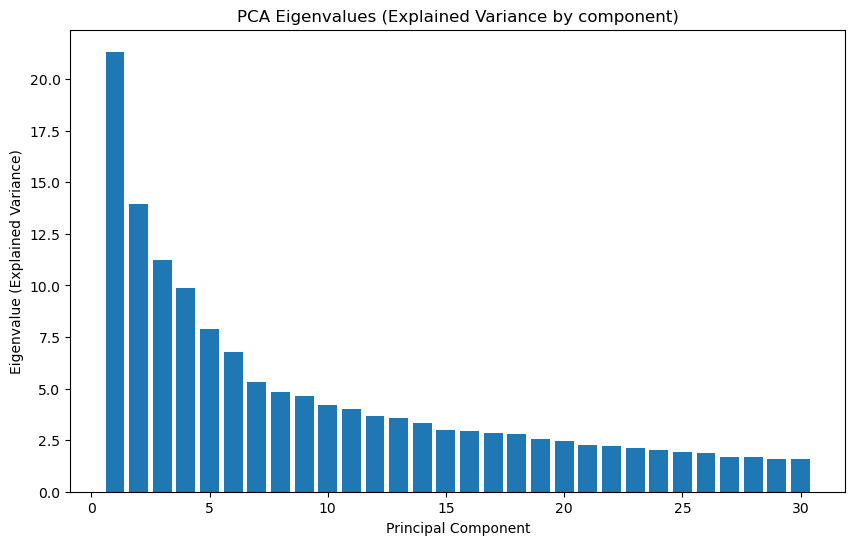

In [70]:
#  write code to create bar plot of eigenvalues from X_filtered

#  hint: you can get eigenvalues only from PCA

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# X_filtered is now our feature matrix 

# Normalize x filtered

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_filtered)

pca = PCA()
pca.fit(X_normalized)

# Get the eigenvalues that explain the variance of the dataset
eigenvalues = pca.explained_variance_

eigenvalues = eigenvalues[:30]


# Plot this shit

plt.figure(figsize=(10,6))
plt.bar(range(1,len(eigenvalues)+ 1), eigenvalues)
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue (Explained Variance)")
plt.title("PCA Eigenvalues (Explained Variance by component)")
plt.show()

Step 3: determining the optimal number of principal components for PCA [https://www.linkedin.com/advice/3/how-can-you-determine-optimal-number-principal-4opaf, https://drlee.io/the-ultimate-step-by-step-guide-to-data-mining-with-pca-and-kmeans-83a2bcfdba7d]

Once the data is denoised, the next step in using Principal Component Analysis (PCA) is to determine the optimal number of principal components to retain. This decision is crucial as it influences the effectiveness of PCA in capturing the essential variance of your data.

The concept of explained variance

- Explained Variance: PCA transforms the original variables into a new set of variables, the principal components, which are ordered by the amount of variance they capture from the data. The ‘explained variance’ indicates how much information (variance) each principal component holds.
- Cumulative Explained Variance: by summing the explained variances of successive principal components, we can understand how many components are necessary to capture a significant portion of the total variance in the dataset.


In [47]:
# Fit PCA on filtered dataset (without limiting components)
pca_filtered = PCA()
pca_filtered.fit(X_filtered)

# Calculate explained variance
explained_variance = pca_filtered.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

It's implemented using cumulative variance plots with 80%, 90%, and 95% thresholds, allowing you to choose based on your needs.

optimal number of components for 80% Variance:  38
optimal number of components for 90% Variance:  67
optimal number of components for 95% Variance:  96


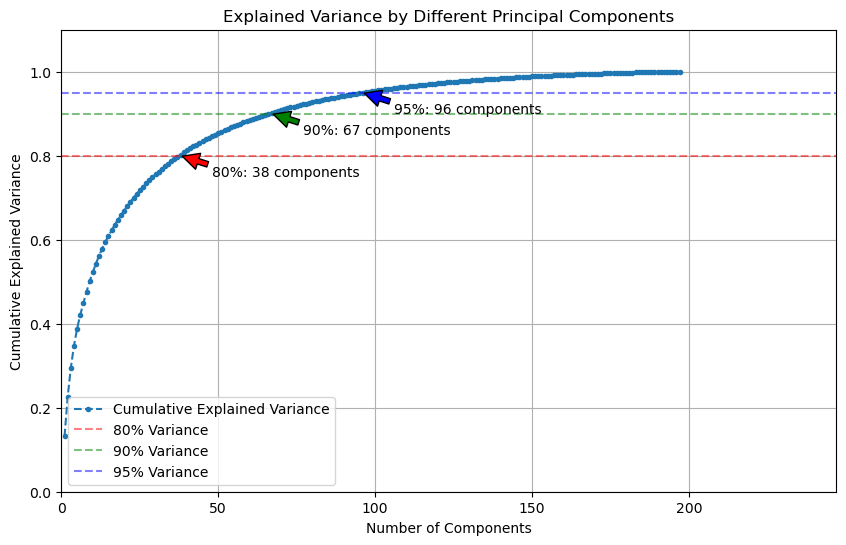

In [48]:
# Plot the explained variance
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.', linestyle='--')

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Different Principal Components')

plt.xlim(0, len(cumulative_variance) + 50)
plt.ylim(0, 1.1)

plt.grid(True)

# Add reference lines for common thresholds
plt.axhline(y=0.8, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=0.9, color='g', linestyle='--', alpha=0.5)
plt.axhline(y=0.95, color='b', linestyle='--', alpha=0.5)
plt.legend(['Cumulative Explained Variance', '80% Variance', '90% Variance', '95% Variance'])

# Find optimal number of components for different thresholds
optimal_80 = np.where(cumulative_variance >= 0.8)[0][0] + 1
optimal_90 = np.where(cumulative_variance >= 0.9)[0][0] + 1
optimal_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1

print("optimal number of components for 80% Variance: ", optimal_80)
print("optimal number of components for 90% Variance: ", optimal_90)
print("optimal number of components for 95% Variance: ", optimal_95)

# Annotate the plot with the optimal numbers
plt.annotate(f'80%: {optimal_80} components', 
             xy=(optimal_80, 0.8), 
             xytext=(optimal_80+10, 0.75),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.annotate(f'90%: {optimal_90} components', 
             xy=(optimal_90, 0.9), 
             xytext=(optimal_90+10, 0.85),
             arrowprops=dict(facecolor='green', shrink=0.05))

plt.annotate(f'95%: {optimal_95} components', 
             xy=(optimal_95, 0.95), 
             xytext=(optimal_95+10, 0.9),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.savefig('pca_variance_explained.png')
plt.show()


This graph will help you visually identify the “elbow” point. Once identified, you can set the number of components in PCA accordingly:

In [49]:
print(f"Number of components needed for 80% variance: {optimal_80}")
print(f"Number of components needed for 90% variance: {optimal_90}")
print(f"Number of components needed for 95% variance: {optimal_95}")

Number of components needed for 80% variance: 38
Number of components needed for 90% variance: 67
Number of components needed for 95% variance: 96


Applying PCA with optimal components: now you need to select components that explain 80/90/95% of variance as a balanced approach. You need to select it by yourself.

PCA works by identifying directions, or 'principal components', in which the data varies the most. It essentially reorients your data, projecting it onto these new axes to capture the essence of the original features with fewer dimensions.

In this step, you’ve determined how many principal components are sufficient to capture the major variance in our dataset without overwhelming it with dimensions. This sets the stage for applying PCA and transforming your data, which we’ll cover in the next step.

In [50]:
n_components =  67

Step 4: Apply PCA with the optimal number of components

With the optimal number of principal components determined, it’s time to apply PCA to your data. This step is about transforming your scaled features into a new, lower-dimensional space while retaining the most important information.

In [51]:
print(f"\nApplying PCA with {n_components} components")

# Applying PCA with the optimal number of components
pca = PCA(
    n_components=n_components, 
    random_state=41,  # Add this to ensure SVD calculations are deterministic
    svd_solver='arpack'  # Using arpack helps ensure consistent results
)

# The pca_result is an array with the transformed features
pca_result = pca.fit_transform(X_filtered)
print(f"PCA-transformed data shape: {pca_result.shape}")


Applying PCA with 67 components
PCA-transformed data shape: (3815, 67)


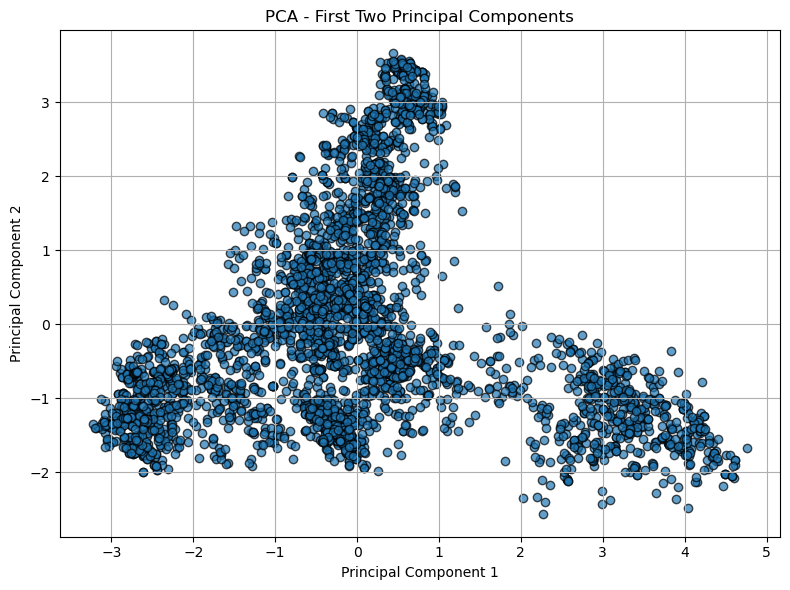

In [52]:
# Plot PCA using 2D plot
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], alpha=0.7, edgecolors="k")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - First Two Principal Components")
plt.grid(True)
plt.tight_layout()
plt.show()

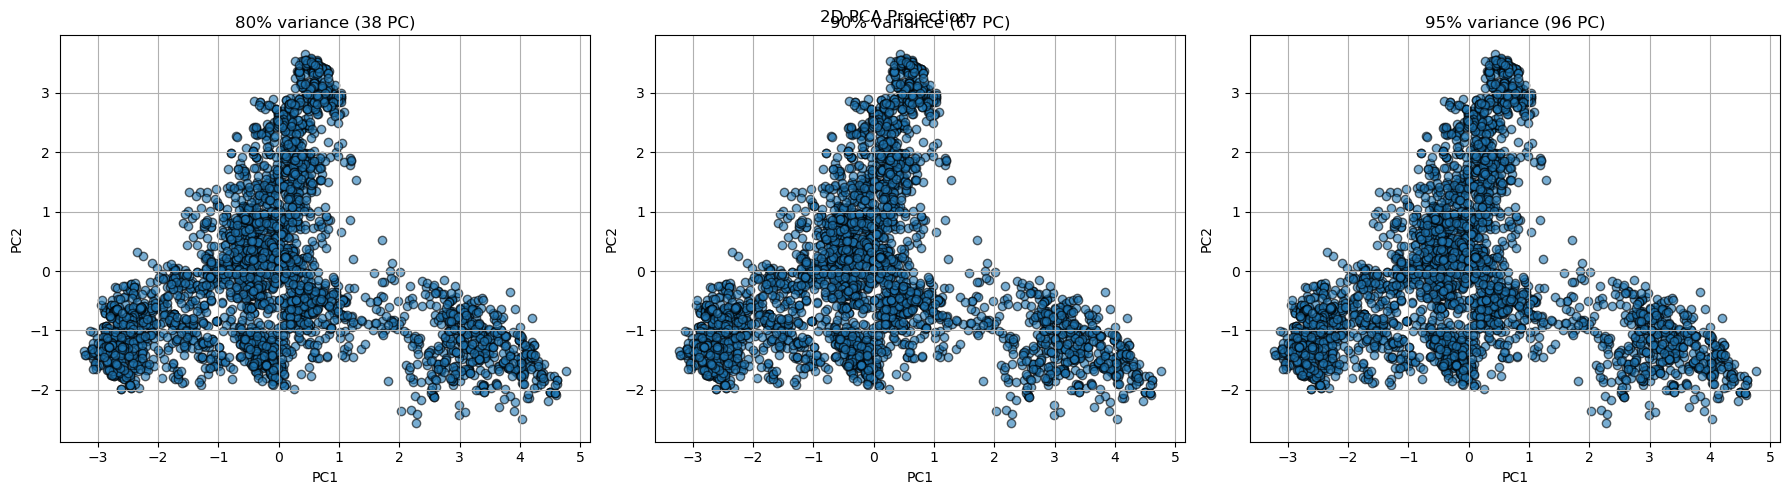

In [53]:
# What we now do is plot them all in a side by side just to get a good look
# on how much of stuff changes with the 

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_filtered)

component_targets = {
    "80% variance (38 PC)": 38,
    "90% variance (67 PC)": 67,
    "95% variance (96 PC)": 96
}

fig,axes = plt.subplots(1,3, figsize=(18,5))

for ax,(label,n_comp) in zip(axes, component_targets.items()):
    pca = PCA(n_components=n_comp,
              random_state=41,
              svd_solver="arpack")
    ax.scatter(pca_result[:,0], pca_result[:,1], alpha=0.6, edgecolor="k")
    ax.set_title(label)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True)

plt.tight_layout()
plt.suptitle("2D PCA Projection")
plt.show()

What can you see on the plot? Can you distinguish separate clusters? Explain it.

In [54]:
print(f"You reduced dimensions of your data from {X.shape[1]} (shape is {X.shape}) to {pca_result.shape[1]} (shape is {pca_result.shape})")

You reduced dimensions of your data from 2048 (shape is (3815, 2048)) to 67 (shape is (3815, 67))


By applying PCA, you’ve taken a significant step in data reduction, distilling your dataset to its most informative features. This not only aids in visualization but also sets the foundation for further analysis, such as clustering.

Now let's finally apply KMeans clustering algorithm to your data. KMeans is a popular unsupervised learning technique used to identify clusters in data. KMeans clustering aims to partition the data into K distinct clusters. The algorithm assigns each data point to the nearest cluster center, with the goal of minimizing the within-cluster variances.

**Questions to answer**:

Which other dimensionality reduction techniques can be applied in out case? Differences between them? Pros / cons of them in comparison to PCA?

Step 5: Determine the optimal number of clusters using Elbow Method and Silhouette scores.

This number can be determined based on domain knowledge, heuristics, or methods like Elbow Method or Silhouette score.


Determining optimal number of clusters with different methods.


[0.1662863094845276, 0.14300479114791084, 0.1561571395397061, 0.1630696066955229, 0.1699831591436982, 0.16921407342552175, 0.16431783892743013, 0.1672568280164226, 0.16191837088844832]


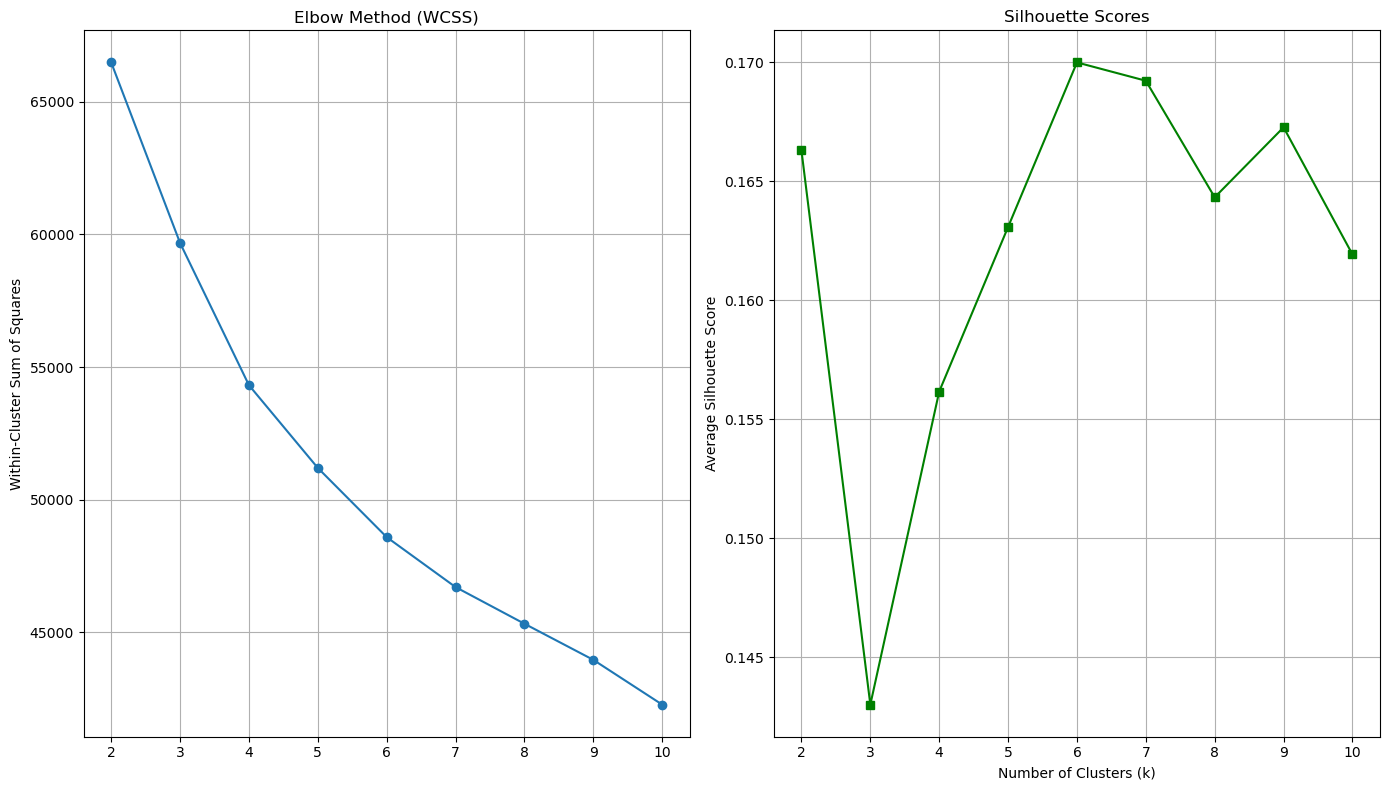

In [55]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("\nDetermining optimal number of clusters with different methods.")
wcss = []  # Within-Cluster Sum of Squares
silhouette_scores = []  # Silhouette scores for different k values
max_clusters = min(10, len(ligand_df))  # Set an upper limit for number of clusters

# here we calculate silhouette scores and wcss for kmean with different numbers of clusters to compare them and select best option
for i in range(2, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(pca_result)
    wcss.append(kmeans.inertia_)
    score = silhouette_score(pca_result, kmeans.labels_)
    silhouette_scores.append(score)

print(silhouette_scores)


# Silhouette value is a measure how similar an object is to its own cluster
# Silhouette value ranges from -1, +1 

k_range = list(range(2, max_clusters +1))

fig,ax = plt.subplots(1,2, figsize=(14,8))
ax[0].plot(k_range, wcss, marker="o")
ax[0].set_title("Elbow Method (WCSS)")
ax[0].set_ylabel("Within-Cluster Sum of Squares")
ax[0].grid(True)

ax[1].plot(k_range,silhouette_scores,marker="s",color="green")
ax[1].set_title("Silhouette Scores")
ax[1].set_xlabel("Number of Clusters (k)")
ax[1].set_ylabel("Average Silhouette Score")
ax[1].grid(True)

plt.tight_layout()
plt.show()



Read about both of them to find proper solution: https://builtin.com/data-science/elbow-method.

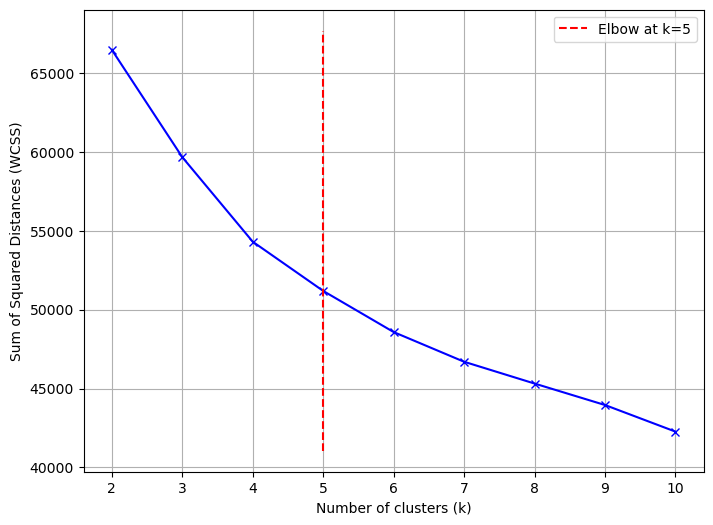

In [56]:
# Find the Ellbow in the Ellbow method

from kneed import KneeLocator


k_range = list(range(2, max_clusters +1))

kn = KneeLocator(k_range,wcss,curve="convex",direction="decreasing")

plt.figure(figsize=(8,6))
plt.plot(k_range,wcss,"bx-")
plt.vlines(kn.knee, plt.ylim()[0],plt.ylim()[1], ls="dashed",color="red",label=f"Elbow at k={kn.knee}")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Sum of Squared Distances (WCSS)")
plt.legend()
plt.grid(True)
plt.show()

optimal_clusters_elbow = kn.knee


In [57]:
print(f"Optimal clusters based on Elbow Method: {optimal_clusters_elbow}")

Optimal clusters based on Elbow Method: 5


Max Silhouette Score: 0.1699831591436982
Silhouette Scores: [0.1662863094845276, 0.14300479114791084, 0.1561571395397061, 0.1630696066955229, 0.1699831591436982, 0.16921407342552175, 0.16431783892743013, 0.1672568280164226, 0.16191837088844832]


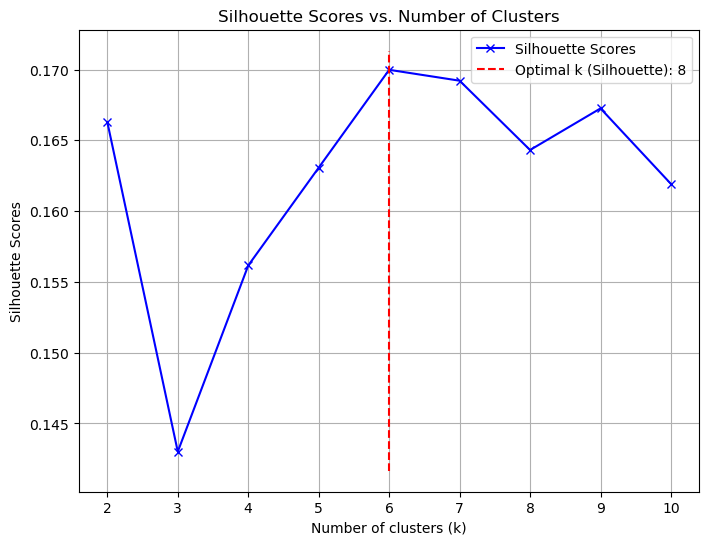

In [58]:

# Find the max silhouette score and its index
max_silhouette_scores = max(silhouette_scores)
optimal_clusters_silhouette = silhouette_scores.index(max_silhouette_scores) +2

print(f"Max Silhouette Score: {max_silhouette_scores}")
print(f"Silhouette Scores: {silhouette_scores}")

# Plotting the Silhouette Scores
plt.figure(figsize=(8,6))
plt.plot(k_range, silhouette_scores, "bx-", label="Silhouette Scores")
plt.vlines(optimal_clusters_silhouette, plt.ylim()[0], plt.ylim()[1], ls="dashed", color="red", label=f"Optimal k (Silhouette): {optimal_clusters_silhouette + 2}")


plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Scores")
plt.title("Silhouette Scores vs. Number of Clusters")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
print(f"Optimal clusters based on Silhouette Score: {optimal_clusters_silhouette}")

Optimal clusters based on Silhouette Score: 6


In [60]:
# Choose the optimal number of clusters (can be based on either method or domain knowledge)
n_clusters = optimal_clusters_silhouette  # Using elbow score as primary metric
print(f"\nSelected {n_clusters} clusters for KMeans")


Selected 6 clusters for KMeans


**Question to answer**: 

- Difference between Elbow Method and Silhouette Method? In which cases which one is better to use?

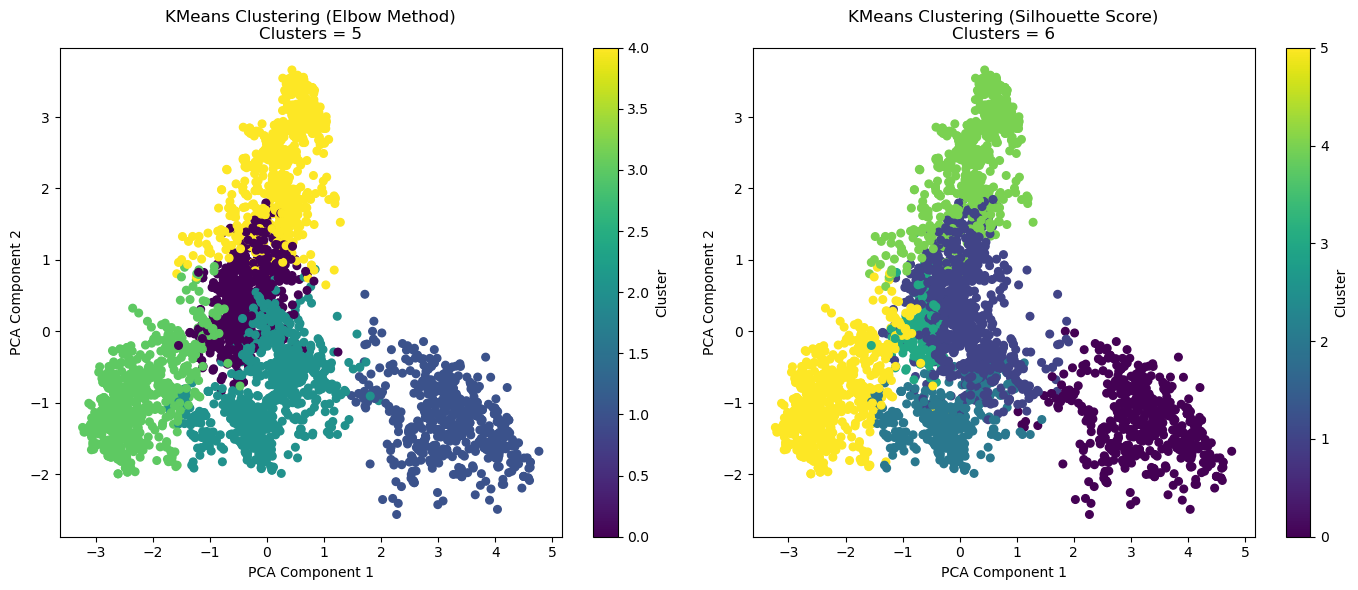

In [61]:
# Apply KMeans with the optimal number of clusters = n_clusters
# use KMeans from https://scikit-learn.org/stable/modules/clustering.html

from sklearn.cluster import KMeans

# Step 1: Apply KMeans with the optimal number of clusters from the Elbow Method
kmeans_elbow = KMeans(n_clusters=kn.knee, random_state=42, n_init=10)
kmeans_elbow.fit(pca_result)
labels_elbow = kmeans_elbow.labels_

# Step 2: Apply KMeans with the optimal number of clusters from the Silhouette Score
kmeans_silhouette = KMeans(n_clusters=optimal_clusters_silhouette, random_state=42, n_init=10)
kmeans_silhouette.fit(pca_result)
labels_silhouette = kmeans_silhouette.labels_



plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels_elbow, cmap='viridis', s=30)
plt.title(f'KMeans Clustering (Elbow Method)\nClusters = {kn.knee}')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')

# Plot the clusters based on Silhouette Score (optimal_clusters_silhouette)
plt.subplot(1, 2, 2)
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels_silhouette, cmap='viridis', s=30)
plt.title(f'KMeans Clustering (Silhouette Score)\nClusters = {optimal_clusters_silhouette}')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')

# Show the plots side by side
plt.tight_layout()
plt.show()

In [62]:
# get cluster labels
cluster_labels = kmeans_elbow.labels_

In [63]:
# Add cluster labels to the original dataframe (for each molecule) in separate 'cluster' column

ligand_df["cluster"] = cluster_labels

print(ligand_df["cluster"])

0       0
1       0
2       0
3       0
4       0
       ..
3810    3
3811    2
3812    4
3813    1
3814    0
Name: cluster, Length: 3815, dtype: int32


Let's check which molecules have been assigned to which clusters and how uniform this distribution is - make conclusions based on it.

---------Cluster Distribution--------------
cluster
0    790
1    562
2    938
3    766
4    759
Name: count, dtype: int64


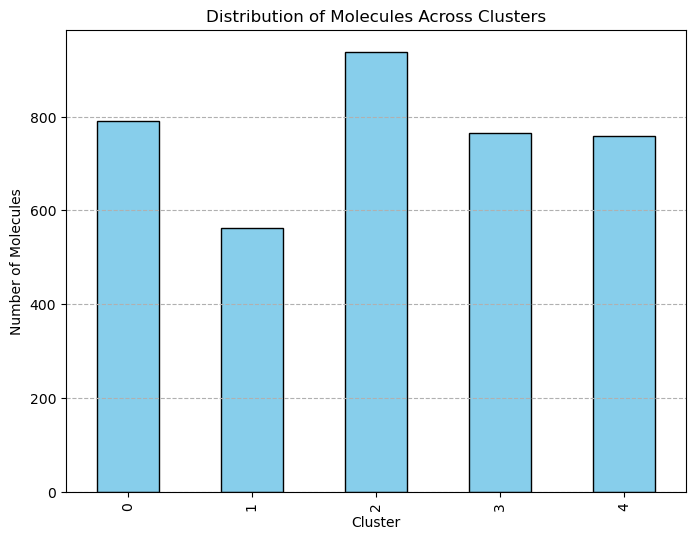

In [64]:
# code for checking distribution of the molecules between clusters

# Count the Individual values for the different molecules in the ligand df

cluster_distribution = ligand_df["cluster"].value_counts().sort_index()

print("---------Cluster Distribution--------------")
print(cluster_distribution)

plt.figure(figsize=(8,6))
cluster_distribution.plot(kind="bar",color="skyblue",edgecolor="black")
plt.title("Distribution of Molecules Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Molecules")
plt.grid(True, axis="y", ls="--")
plt.show()

In [65]:
# rename the columns in 
print(ligand_df.columns)

ligand_df =  ligand_df.rename(columns={"mol":"Molecule"})
ligand_df.head(2)

Index(['Unnamed: 0', 'molecule_chembl_id', 'units', 'IC50', 'canonical_smiles',
       'pIC50', 'mols', 'mol', 'morgan_fp', 'morgan_fingerprint_bit',
       'cluster'],
      dtype='object')


Unnamed: 0 molecule_chembl_id units      IC50   
0           0        CHEMBL93558    nM  217000.0  \
1           1       CHEMBL443622    nM   41000.0   

                  canonical_smiles     pIC50   
0  N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1  2.663540  \
1            C[C@H](N)C(=O)N1CCCC1  3.387216   

                                               mols   
0  <rdkit.Chem.rdchem.Mol object at 0x7f870fd61bd0>  \
1  <rdkit.Chem.rdchem.Mol object at 0x7f870fd63f40>   

                                           Molecule   
0  <rdkit.Chem.rdchem.Mol object at 0x7f994c563ca0>  \
1  <rdkit.Chem.rdchem.Mol object at 0x7f994c563c30>   

                                           morgan_fp   
0  [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  \
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                              morgan_fingerprint_bit  cluster  
0  [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        0  
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        0

In [73]:
import mols2grid
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from IPython.display import display

# Create a function to display molecules for a specific cluster
def display_cluster_molecules(df, cluster_num, max_mols=100):
    """
    Display molecules from a specific cluster using mols2grid
    
    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame containing molecule information and cluster assignments
    cluster_num : int
        Cluster number to display
    max_mols : int
        Maximum number of molecules to display (for performance)
    """
    # Filter DataFrame for the specific cluster
    cluster_df = df[df['cluster'] == cluster_num].copy()
    
    # If too many molecules, take a sample
    if len(cluster_df) > max_mols:
        print(f"Cluster {cluster_num} has {len(cluster_df)} molecules. Showing a random sample of {max_mols}.")
        cluster_df = cluster_df.sample(max_mols, random_state=42)
    else:
        print(f"Showing all {len(cluster_df)} molecules in Cluster {cluster_num}.")
    
    # Ensure molecules are ready for visualization
    # If molecules are already RDKit mol objects, use them directly
    if 'Mol' in cluster_df.columns:
        cluster_df['Molecule'] = cluster_df['Mol']
    # Otherwise create molecules from SMILES
    elif 'smiles' in cluster_df.columns:
        cluster_df['Molecule'] = cluster_df['smiles'].apply(Chem.MolFromSmiles)
    else:
        raise ValueError("DataFrame must contain either 'Mol' or 'smiles' column")
    
    # Calculate 2D coordinates for proper rendering
    for mol in cluster_df['Molecule']:
        if mol is not None:  # Avoid errors with invalid molecules
            AllChem.Compute2DCoords(mol)
    
    # Create a column for mols2grid subset filtering that shows the cluster
    cluster_df['Cluster'] = f"Cluster {cluster_num}"
    
    # Display molecules in an interactive grid
    view = mols2grid.display(
        cluster_df,
        mol_col="Molecule",
        subset=["Cluster", "img"],
        tooltip=["molecule_chembl_id", "Cluster", "pIC50"],
        size=(200, 200),  # Adjust size of each molecule cell
        n_cols=5,  # Number of columns in the grid
        useSVG=True,  # Use SVG for better rendering
    )
    display(view)
    
    return cluster_df  # Return the filtered dataframe for potential further analysis

# Function to explore all clusters with control over which to display
def explore_all_clusters(df, max_mols_per_cluster=50):
    """
    Explore all clusters in the dataset
    
    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame containing molecule information and cluster assignments
    max_mols_per_cluster : int
        Maximum number of molecules to display per cluster
    """
    # Get cluster distribution
    cluster_counts = df['cluster'].value_counts().sort_index()
    print("Cluster distribution:")
    for cluster, count in cluster_counts.items():
        print(f"Cluster {cluster}: {count} molecules")
    
    # Create a combined DataFrame for all clusters with samples
    all_clusters_df = pd.DataFrame()
    
    # Get samples from each cluster and combine
    for cluster in cluster_counts.index:
        cluster_df = df[df['cluster'] == cluster].copy()
        
        # Take a sample if needed
        if len(cluster_df) > max_mols_per_cluster:
            cluster_df = cluster_df.sample(max_mols_per_cluster, random_state=42)
        
        # Prepare molecules
        if 'Mol' in cluster_df.columns:
            cluster_df['Molecule'] = cluster_df['Mol']
        elif 'smiles' in cluster_df.columns:
            cluster_df['Molecule'] = cluster_df['smiles'].apply(Chem.MolFromSmiles)
        
        # Add cluster information
        cluster_df['Cluster'] = f"Cluster {cluster}"
        
        # Calculate 2D coordinates
        for mol in cluster_df['Molecule']:
            if mol is not None:
                AllChem.Compute2DCoords(mol)
        
        # Add to combined DataFrame
        all_clusters_df = pd.concat([all_clusters_df, cluster_df])
    
    # Display molecules from all clusters
    view = mols2grid.display(
        all_clusters_df,
        mol_col="Molecule",
        subset=["Cluster", "img"],  # Allow filtering by cluster
        tooltip=["molecule_chembl_id", "Cluster", "pIC50"],
        size=(150, 150),
        n_cols=6,
        useSVG=True,
    )
    display(view)


# explore all clusters with an interactive viewer: all at once 
explore_all_clusters(ligand_df, max_mols_per_cluster=50)

Cluster distribution:
Cluster 0: 790 molecules
Cluster 1: 562 molecules
Cluster 2: 938 molecules
Cluster 3: 766 molecules
Cluster 4: 759 molecules


Let's check in which cluster our ligand molecule (AFATINIB; ligand known to be active to your specific target) were added and which other molecules can be found with it. 

Let's find it by it's CHEMBL ID that we found on prev step (during Virtual screening using similarity search). 

Make conclusion about similarity of the molecules (by structure) that we got within one cluster using Kmean method.

In [94]:
# Find which cluster contains our target molecule (previously you saved this data in 'cluster' column)

target_molecule_id = "CHEMBL1422"


target_molecule= ligand_df[ligand_df["molecule_chembl_id"] == target_molecule_id]

# Check if the target molecule exists

if not target_molecule.empty:
    # Retreve Cluster
    cluster = target_molecule["cluster"].values[0]
    print(f"The molecule {target_molecule_id} is in cluster {cluster}.")
else:
    print(f"Molecule {target_molecule_id} not found in the dataset.")

The molecule CHEMBL1422 is in cluster 3.


In [97]:
# Count how many molecules are in this cluster

molecules_in_cluster = ligand_df[ligand_df["cluster"]==cluster]
num_molecules_in_cluster = molecules_in_cluster.shape[0]

print("Number of Molecules in Cluster", num_molecules_in_cluster)

Number of Molecules in Cluster 766


In [114]:
# Show 15-30 molecules from same cluster as grid image so you can compare them with AFATINIB. Make conclusion on their similarity 
sample_size= 20
sampled_cluster_df = molecules_in_cluster.sample(n=sample_size)

view = mols2grid.display(
        sampled_cluster_df,
        mol_col="Molecule",
        subset=["cluster","img"],
        tooltip=["molecule_chembl_id","cluster","pIC50"],
        n_cols=5,
        useSVG=True
    )
display(view)

In [116]:
# Create a basic visualization of entire cluster with mols2grid (like in example above)

view = mols2grid.display(
    molecules_in_cluster,
    mol_col = "Molecule",
    subset=["cluster","img"],
    tooltip=["molecule_chembl_id","cluster","pIC50"],
    size=(150,150),
    n_cols=5,
    useSVG=True
)
display(view)

Now let's visualize clusters in 2d space.


Visualizing clusters in 2D PCA space


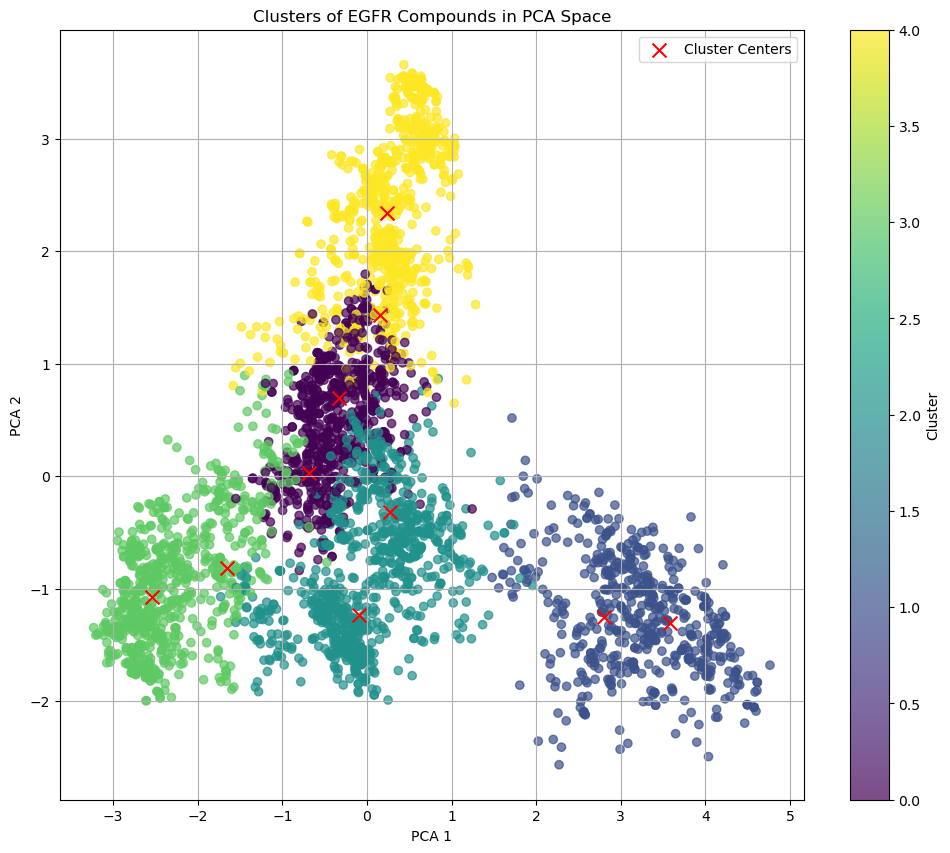

In [117]:
# Visualize the clusters in 2D PCA space
print("\nVisualizing clusters in 2D PCA space")
# Create a 2D visualization of the first two principal components
plt.figure(figsize=(12, 10))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Cluster')

# Mark the cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=100, label='Cluster Centers')

plt.title('Clusters of EGFR Compounds in PCA Space')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.savefig('clusters_2d_visualization.png')
plt.show()

...and in 3d space.

In [118]:
# Alternative: Interactive 3D visualization with Plotly
print("\nCreating interactive 3D visualization with Plotly")

# Import plotly
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from plotly.subplots import make_subplots

# Create a DataFrame for easy plotting with Plotly
plot_df = pd.DataFrame({
    'PCA1': pca_result[:, 0],
    'PCA2': pca_result[:, 1],
    'PCA3': pca_result[:, 2],
    'Cluster': cluster_labels.astype(str),  # Convert to string for discrete color mapping
    'pIC50': ligand_df['pIC50'].values  # Include pIC50 for additional context
})

# Start with an empty figure with a 3D scene
fig = make_subplots(rows=1, cols=1, specs=[[{'type': 'scatter3d'}]])

# Get a colormap that matches the 'viridis' used in matplotlib
# This ensures consistency between 2D and 3D plots
cluster_ids = sorted(plot_df['Cluster'].unique())
n_clusters = len(cluster_ids)
colorscale = px.colors.sequential.Viridis
colors = [colorscale[int(i * len(colorscale) / n_clusters)] for i in range(n_clusters)]

# Create color mapping dictionary
color_map = dict(zip(cluster_ids, colors))

# Add data points cluster by cluster to ensure correct coloring
for cluster_id in cluster_ids:
    cluster_data = plot_df[plot_df['Cluster'] == cluster_id]
    
    fig.add_trace(go.Scatter3d(
        x=cluster_data['PCA1'],
        y=cluster_data['PCA2'],
        z=cluster_data['PCA3'],
        mode='markers',
        marker=dict(
            size=3,  # Smaller point size makes visualization less cluttered
            color=color_map[cluster_id],
            opacity=0.7,
            symbol='circle'
        ),
        name=f'Cluster {cluster_id}',
        hovertemplate='<b>Cluster:</b> %{text}<br>'
                      '<b>PCA1:</b> %{x:.4f}<br>'
                      '<b>PCA2:</b> %{y:.4f}<br>'
                      '<b>PCA3:</b> %{z:.4f}<br>'
                      '<b>pIC50:</b> %{customdata:.2f}',
        text=[cluster_id] * len(cluster_data),
        customdata=cluster_data['pIC50']
    ))

# Add cluster centers with plus symbols
for i in range(len(centers)):
    fig.add_trace(go.Scatter3d(
        x=[centers[i, 0]],
        y=[centers[i, 1]],
        z=[centers[i, 2]],
        mode='markers',
        marker=dict(
            color='red',
            size=15,  # Larger size for visibility
            symbol='cross',  # This gives you the "+" shape
            line=dict(width=2, color='black')  # Add outline for better visibility
        ),
        name=f'Center {i}',
        hoverinfo='name'
    ))

# Update layout for better visualization
fig.update_layout(
    title='Interactive 3D Visualization of EGFR Compound Clusters',
    scene=dict(
        xaxis_title='Principal Component 1',
        yaxis_title='Principal Component 2',
        zaxis_title='Principal Component 3',
        # Adding more grid lines for better spatial perception
        xaxis=dict(showgrid=True, gridwidth=1, gridcolor='lightgray'),
        yaxis=dict(showgrid=True, gridwidth=1, gridcolor='lightgray'),
        zaxis=dict(showgrid=True, gridwidth=1, gridcolor='lightgray')
    ),
    width=1000,
    height=800,
    legend=dict(
        itemsizing='constant',  # Makes legend items a constant size
        title="Clusters",
        font=dict(size=10)
    ),
    margin=dict(l=0, r=0, t=40, b=0)  # Tight margins for more space
)

# Save as HTML file that can be interactively explored in a browser
fig.write_html('interactive_3d_clusters.html')

# Show the plot
fig.show()


Creating interactive 3D visualization with Plotly


If you can't see dots on this interactive plot - please open 'interactive_3d_clusters.html' in your browser for that.

Make conclusions based on seen clusters distribution in 2d and 3d space.

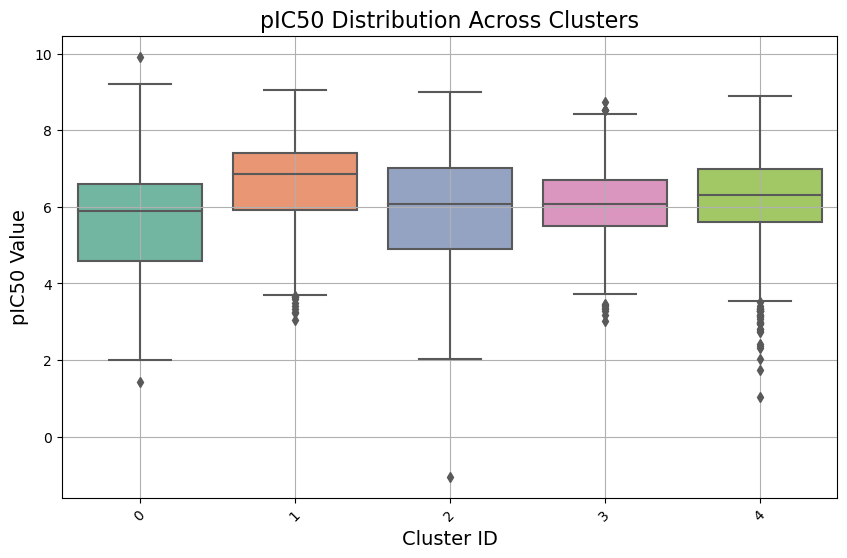

In [119]:
# Analyze pIC50 distribution across clusters
# Create a boxplot showing pIC50 distribution by cluster
# make conclusions about pIC50 distribution within and between clusters. Evaluate effectivity of the clustering algorithm based on it

import seaborn as sns
import matplotlib.pyplot as plt

if "pIC50" in ligand_df.columns and "cluster" in ligand_df.columns:
    # Create a boxplot to visualize the distribution
    plt.figure(figsize=(10,6))
    sns.boxplot(x="cluster",y="pIC50",data=ligand_df,palette="Set2")

    # Add labels
    plt.title("pIC50 Distribution Across Clusters", fontsize=16)
    plt.xlabel("Cluster ID", fontsize=14)
    plt.ylabel("pIC50 Value", fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

**Task**: try to perform same analysis using other DR methods:
- t-SNE: https://www.youtube.com/watch?v=NEaUSP4YerM&ab_channel=StatQuestwithJoshStarmer, https://readmedium.com/how-t-sne-outperforms-pca-in-dimensionality-reduction-7a3975e8cbdb, https://distill.pub/2016/misread-tsne/, https://medium.com/data-science/how-to-tune-hyperparameters-of-tsne-7c0596a18868, https://www.reddit.com/r/MachineLearning/comments/tq1ia3/r_new_tsne_guidelines_an_experimental_study_and/, https://rpubs.com/TusVasMit/T-SNEExploration, https://www.sciencedirect.com/science/article/pii/S2468502X22000201, https://towardsdatascience.com/t-sne-machine-learning-algorithm-a-great-tool-for-dimensionality-reduction-in-python-ec01552f1a1e/

- UMAP: https://github.com/NikolayOskolkov/HowUMAPWorks/blob/master/HowUMAPWorks.ipynb, https://readmedium.com/how-exactly-umap-works-13e3040e1668, https://link.springer.com/chapter/10.1007/978-3-030-88389-8_9, https://towardsdatascience.com/umap-dimensionality-reduction-an-incredibly-robust-machine-learning-algorithm-b5acb01de568/, https://jlmelville.github.io/uwot/articles/umap-for-tsne.html, https://corinwagen.github.io/public/blog/20220926_plotting_diversity.html

About DR: https://corinwagen.github.io/public/blog/20230417_dimensionality_reduction, https://github.com/rdkit/rdkit-tutorials/blob/master/notebooks/005_Chemical_space_analysis_and_visualization.ipynb?utm_source=chatgpt.com

-------

## Density-based clustering methods (DBSCAN/HDBSCAN)

Literature to read: 

https://builtin.com/articles/dbscan

https://medium.com/@tarammullin/dbscan-parameter-estimation-ff8330e3a3bd

https://stackoverflow.com/questions/15050389/estimating-choosing-optimal-hyperparameters-for-dbscan 

https://blog.dailydoseofds.com/p/how-to-find-optimal-epsilon-value

https://stackoverflow.com/questions/63799332/how-determine-optimal-epsilon-value-in-meters-for-dbscan-by-plotting-knn-elbow 

https://stataiml.com/posts/how_to_set_dbscan_paramter/ 

https://www.datacamp.com/tutorial/dbscan-clustering-algorithm

https://www.kaggle.com/code/tanmaymane18/nearestneighbors-to-find-optimal-eps-in-dbscan 

https://medium.com/data-science/tuning-with-hdbscan-149865ac2970 

https://medium.com/@sachinsoni600517/clustering-like-a-pro-a-beginners-guide-to-dbscan-6c8274c362c4

https://medium.com/@mohantysandip/a-step-by-step-approach-to-solve-dbscan-algorithms-by-tuning-its-hyper-parameters-93e693a91289

What you need to use for clustering practical task: https://scikit-learn.org/stable/auto_examples/cluster/plot_hdbscan.html#sphx-glr-auto-examples-cluster-plot-hdbscan-py



Density-based spatial clustering of applications with noise (DBSCAN) is a clustering algorithm used in machine learning to partition data into clusters based on their distance to other points. Its effective at identifying and removing noise in a data set, making it useful for data cleaning and outlier detection. 

For DBSCAN and other density-based clustering algorithms there is another score that defines how well data is clustered.

DBCV (Density-based clustering validation) specifically measures how well-defined your clusters are from a density perspective. Higher DBCV - better clustering.

Let's start with the same - getting prev NOT filtered by RO5 and PAINS data from `csv`.

In [120]:
# Load the CSV file into a pandas DataFrame
filepath = "/home/praktikum/storage/meinschad_lukas_ff_pr/2025/Day_4/bioactivity_and_smiles.csv"
ligand_df_dbscan = pd.read_csv(filepath,sep="\t")

In [125]:
# Generate RDKit molecule objects from SMILES
ligand_df_dbscan["Mol"] = ligand_df_dbscan["canonical_smiles"].apply(Chem.MolFromSmiles)
# Create 'Mol' column containing RDKit molecule objects
ligand_df_dbscan.head(3)

Unnamed: 0 molecule_chembl_id units           IC50   
0           0        CHEMBL93558    nM  217000.000000  \
1           1       CHEMBL443622    nM   41000.000000   
2           2       CHEMBL403882    nM   12971.337244   

                  canonical_smiles     pIC50   
0  N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1  2.663540  \
1            C[C@H](N)C(=O)N1CCCC1  3.387216   
2         O=C([C@@H]1CCCN1)N1CCCC1  3.887015   

                                               mols   
0  <rdkit.Chem.rdchem.Mol object at 0x7f870fd61bd0>  \
1  <rdkit.Chem.rdchem.Mol object at 0x7f870fd63f40>   
2  <rdkit.Chem.rdchem.Mol object at 0x7f870fd610e0>   

                                                Mol  
0  <rdkit.Chem.rdchem.Mol object at 0x7f995be96ab0>  
1  <rdkit.Chem.rdchem.Mol object at 0x7f995be96b20>  
2  <rdkit.Chem.rdchem.Mol object at 0x7f995be96ff0>

In [129]:
# Calculate Morgan fingerprints
# 1. Initialize Morgan fingerprint generator (radius=2, 2048 bits is a common choice for ECFP4 fingerprints)
# 2. Convert fingerprints to numpy arrays for analysis: this step is crucial for converting the RDKit fingerprint objects to a format usable by sklearn
# save them into separate 'morgan_fingerprint_bit_array' column

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)

ligand_df_dbscan["morgan_fingerprint_bit_array"] = ligand_df_dbscan["Mol"].apply(mfpgen.GetFingerprint)
ligand_df_dbscan["morgan_fingerprint_bit_array"] = ligand_df_dbscan["morgan_fingerprint_bit_array"].apply(lambda x: np.array(x))


Get only fingerprints out of dataframe.

Convert them into `np` array, so it would be easier to ...

In [135]:
fps_array = np.array(ligand_df_dbscan["morgan_fingerprint_bit_array"].tolist())


fps_array.shape

(3815, 2048)

... calculate distance matrix out of them.

In [136]:
from sklearn.metrics import pairwise_distances

# use pairwise_distances method from sklearn (metric='jaccard')

distance_matrix = pairwise_distances(fps_array,metric="jaccard")

/usr/local/miniconda3-aq-v1/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2025: DataConversionWarning:

Data was converted to boolean for metric jaccard



In [137]:
# check the shape - it should be square matrix

distance_matrix.shape

(3815, 3815)

Let's plot jaccard distances distribution to find out if we can use this data for density-based clustering.

<Figure size 1000x600 with 0 Axes>

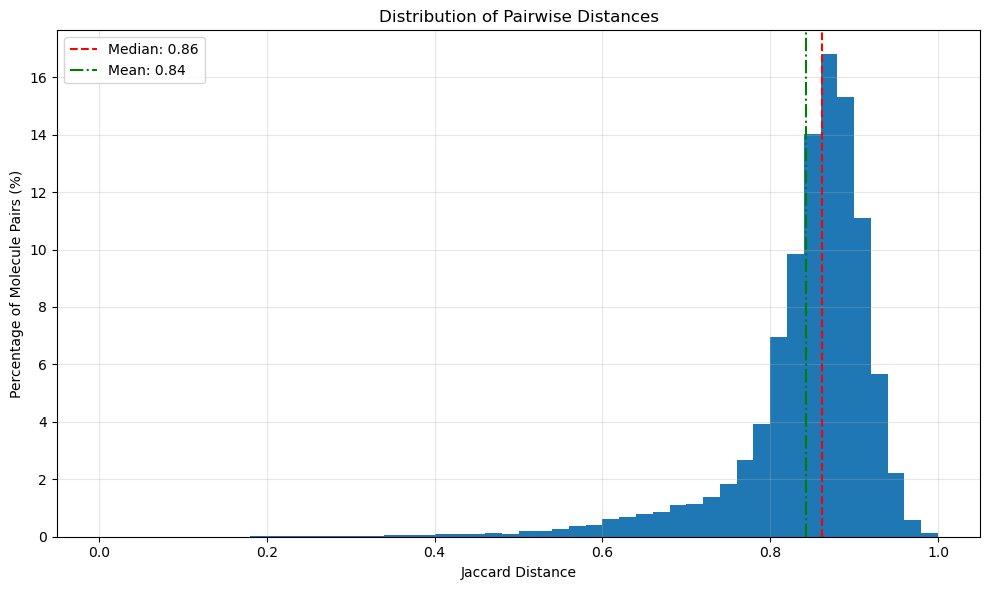

In [138]:
plt.figure(figsize=(10, 6))
# Flatten the distance matrix (excluding diagonal elements)
distances = distance_matrix[np.triu_indices(distance_matrix.shape[0], k=1)]

# Create histogram with density=True to normalize area to 1
counts, bins, _ = plt.hist(distances, bins=50, density=True)

# Calculate bin width
bin_width = bins[1] - bins[0]

# Scale to get percentage per bin (multiplying by bin width and 100)
percentage_per_bin = counts * bin_width * 100

# Clear the previous histogram and create a new one with percentages
plt.clf()
plt.figure(figsize=(10, 6))
plt.bar(bins[:-1], percentage_per_bin, width=bin_width, align='edge')

plt.title('Distribution of Pairwise Distances')
plt.xlabel('Jaccard Distance')
plt.ylabel('Percentage of Molecule Pairs (%)')
plt.grid(True, alpha=0.3)

# Add vertical lines for key statistics
plt.axvline(x=np.median(distances), color='red', linestyle='--', 
           label=f'Median: {np.median(distances):.2f}')
plt.axvline(x=np.mean(distances), color='green', linestyle='-.',
           label=f'Mean: {np.mean(distances):.2f}')
plt.legend()

plt.tight_layout()
plt.show()

From this graph we can see, that: Jaccard distance distribution and peak are heavily concentrated closer to 1. 

This means:
- High overall dissimilarity: most of your data points are quite dissimilar from each other (Jaccard distance of 0 = identical, 1 = completely different)
- Lack of clear clusters: there are very few point pairs with low Jaccard distances (below 0.6), which would normally form the cores of well-defined clusters.
- Uniformly spread dissimilarity: bell-shaped distribution centered at high distance values = your data points exist in a space where everything is somewhat equidistant from everything else.

This can't give you at least positive DBCV scores, because: 
- when most points have similar high distances from each other, density becomes relatively uniform throughout your entire data space (where all the points are equally far away from each other). This happens because of increadibly high dimensionality: with incr. dimensionality distances between most points become increasingly similar --> density variations become less pronounced and harder to detect.
- no clear density valleys - good density-based clustering requires clear separation between high-density regions, but in distribution above these valleys can't be found. Well-defined density structures means: areas of high density that are separated by areas of low density. Your current distance distribution shows very little separation that HDBSCAN can exploit.
- such pattern (with shifting in high distance area) often occurs in high-dimensional data where the "curse of dimensionality" makes everything seem far apart from everything else.

After performing grid-analysis we came to conclusion that such dataset produces only negative DBCV scores what shows not proper density-based clustering.

Conclusion: this chemical space represented by Jaccard distance matrices calculate from Morgan bit fingerprints lacks natural density-based clusters. 

If working with such high-dimensional data, DR might help create clearer cluster structures. Let's try new approach to do that - UMAP. Unlike t-SNE or PCA, UMAP preserves both local and global structure while creating more separated clusters. It helps to create more separated structures. UMAP isn't just any dimensionality reduction technique - it was specifically designed to address clustering challenges (as above).

**Why do we heed DR?**

Not all information in the original distance matrix is equally valuable: the most informative distances are the shorter ones that indicate similar compounds. UMAP selectively preserves the most informative distance relationships

How to select proper paramethers for UMAP read here: https://aicompetence.org/umap-optimization-essential-parameters-for-speed/.

In [139]:
# DR
import umap

# Key parameters optimized for chemical fingerprint distance matrices
umap_reducer = umap.UMAP(
    n_neighbors=15,           # Balance between local and global structure
    min_dist=0.4,             # Create clusters with density = 0.5 (check in the article why)
    n_components=10,          # Higher dimensions preserve more structure for clustering
    metric='precomputed',     # Critical: tells UMAP we're using a distance matrix
    n_epochs=200,             # More epochs for better convergence
    learning_rate=1.0,        
    random_state=42,          # For reproducibility
    low_memory=True,          # Helps with large datasets
    verbose=True              # Show progress
)

umap_embedding = umap_reducer.fit_transform(distance_matrix)


2025-05-08 15:32:16.290938: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-08 15:32:16.550119: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-08 15:32:16.551250: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-08 15:32:17.481796: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/praktikum/.local/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

/home/praktikum/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state.

UMAP(metric='precomputed', min_dist=0.4, n_components=10, n_epochs=200, n_jobs=1, random_state=42, verbose=True)
Thu May  8 15:32:18 2025 Construct fuzzy simplicial set
Thu May  8 15:32:18 2025 Finding Nearest Neighbors
Thu May  8 15:32:21 2025 Finished Nearest Neighbor Search
Thu May  8 15:32:23 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Thu May  8 15:32:26 2025 Finished embedding


Now let's plot results of DR:

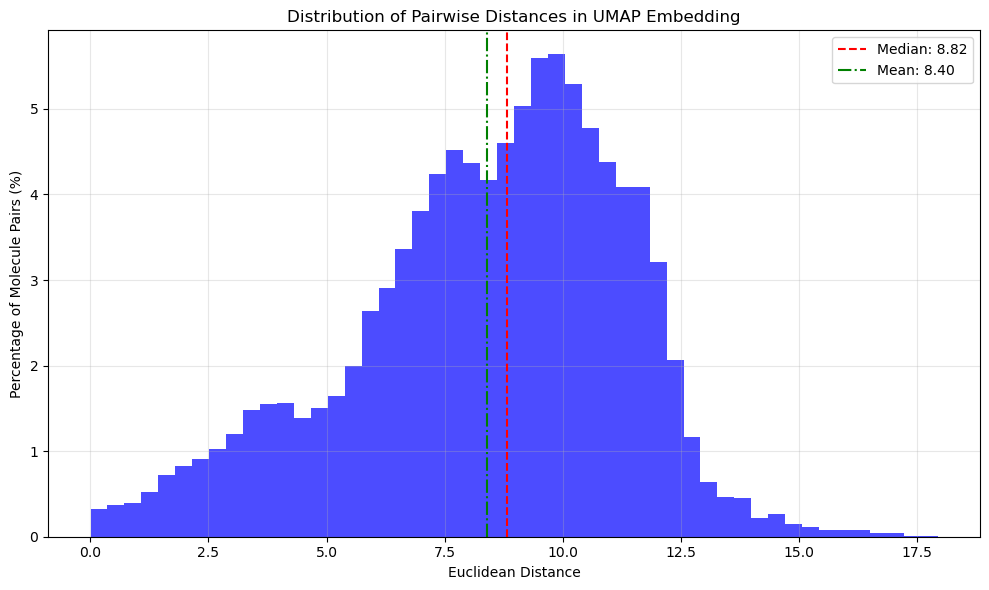

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
import seaborn as sns

# Calculate pairwise distances in the UMAP embedding space
# This computes distances between all pairs of points in your 10D space
embedding_distances = euclidean_distances(umap_embedding)

# Get the upper triangle of the distance matrix (excluding diagonal)
distances_flat = embedding_distances[np.triu_indices(embedding_distances.shape[0], k=1)]


plt.figure(figsize=(10, 6))

# Calculate bin counts with density=True to normalize the area under the histogram
counts, bin_edges, _ = plt.hist(distances_flat, bins=50, density=True, alpha=0)

# Calculate bin width
bin_width = bin_edges[1] - bin_edges[0]

# Convert density to percentage per bin
percentage_per_bin = counts * bin_width * 100

# Create bar plot with percentages
plt.bar(bin_edges[:-1], percentage_per_bin, width=bin_width, alpha=0.7, color='blue', 
        align='edge')

plt.title('Distribution of Pairwise Distances in UMAP Embedding')
plt.xlabel('Euclidean Distance')
plt.ylabel('Percentage of Molecule Pairs (%)')
plt.grid(True, alpha=0.3)

# Add vertical lines for key statistics
plt.axvline(x=np.median(distances_flat), color='red', linestyle='--', 
           label=f'Median: {np.median(distances_flat):.2f}')
plt.axvline(x=np.mean(distances_flat), color='green', linestyle='-.',
           label=f'Mean: {np.mean(distances_flat):.2f}')
plt.legend()

plt.tight_layout()
plt.show()

Now let's compare results before and after DR (normalising them beforehand - otherwise we couldn't compare them):

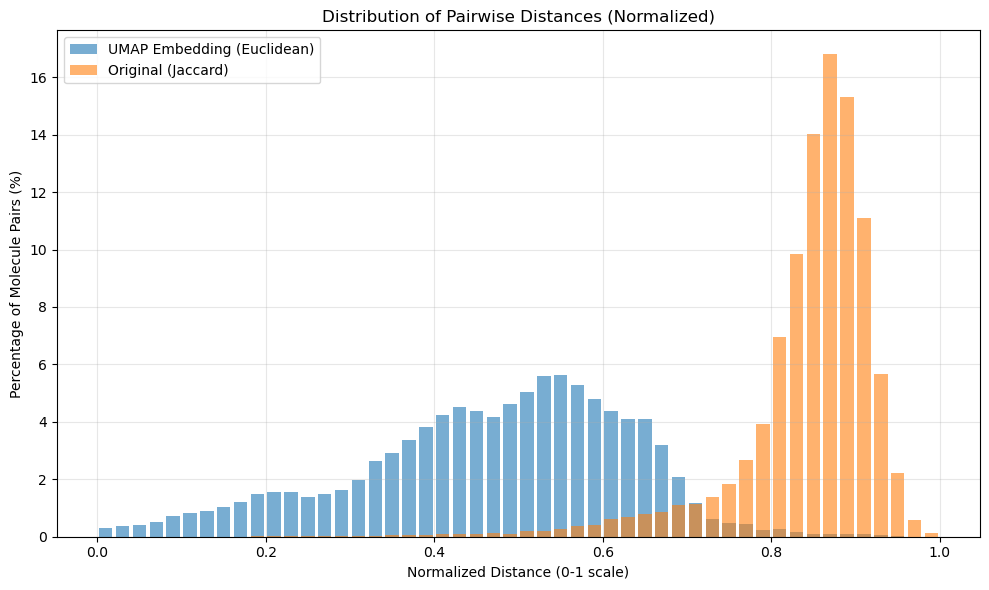

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Assuming you have these distance arrays:
original_distances = distance_matrix[np.triu_indices(distance_matrix.shape[0], k=1)]

umap_distances = embedding_distances[np.triu_indices(embedding_distances.shape[0], k=1)]


# Step 1: Create a common plotting function
def plot_normalized_distributions(dist1, dist2, name1, name2, bins=50):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Normalize both distance arrays to 0-1
    dist1_norm = (dist1 - np.min(dist1)) / (np.max(dist1) - np.min(dist1))
    dist2_norm = (dist2 - np.min(dist2)) / (np.max(dist2) - np.min(dist2))
    
    # Create histograms with percentage frequency
    hist1, bins1 = np.histogram(dist1_norm, bins=bins, density=True)
    hist1 = hist1 * (1.0/bins)  # Scale for percentage per bin
    centers1 = (bins1[:-1] + bins1[1:]) / 2
    
    hist2, bins2 = np.histogram(dist2_norm, bins=bins, density=True)
    hist2 = hist2 * (1.0/bins)  # Scale for percentage per bin
    centers2 = (bins2[:-1] + bins2[1:]) / 2
    
    # Plot with percentage y-axis
    ax.bar(centers1, hist1*100, width=(1/bins)*0.8, alpha=0.6, label=name1)
    ax.bar(centers2, hist2*100, width=(1/bins)*0.8, alpha=0.6, label=name2)
    
    # Clearer labels
    ax.set_xlabel('Normalized Distance (0-1 scale)')
    ax.set_ylabel('Percentage of Molecule Pairs (%)')
    ax.set_title('Distribution of Pairwise Distances (Normalized)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Call the function
plot_normalized_distributions(
    umap_distances,  # The Euclidean distances from UMAP embedding
    original_distances,  # The original Jaccard distances
    'UMAP Embedding (Euclidean)',
    'Original (Jaccard)'
)

From here we can see that UMAP has fundamentally transformed your chemical space in a way that enables effective clustering:

- UMAP has addressed the "curse of dimensionality" problem by redistributing distances from a highly concentrated peak to a natural bell curve
- broader distribution means density variations --> density-based clustering algorithms can detect meaningful variations that were previously hidden --> now algorithm can see clear separation between similar and dissimilar compounds

New dataset gives positive DBCV score, because algorithm can finally detect genuine density differences.

The transformation from the original narrow peak to the broader bell curve is precisely what enables density-based clustering to succeed, validating this approach of using UMAP before HDBSCAN.

Now let's check how clustering with density-based algorithm looks like (and results of this clustering too).

Here you can see clustering with pre-defined `min_cluster_size` and `min_samples`. How you can select them by yourself will be explained later on.

In [216]:
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.cluster import HDBSCAN
import hdbscan
import seaborn as sns
from scipy.spatial.distance import squareform
import pandas as pd

# Initialize and run HDBSCAN with the precomputed matrix
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,    # Minimum cluster size - adjust based on your data
    min_samples=7,          # Minimum samples in neighborhood to be core point
    cluster_selection_method='eom',  # 'eom' (Excess of Mass) often works well
    #n_jobs=42          
)

# Fit the model to your distance matrix
clusterer.fit(umap_embedding)

HDBSCAN(min_cluster_size=25, min_samples=7)

In [217]:
# Analyze the results
labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_points = list(labels).count(-1)

print(f"Number of clusters: {n_clusters}")
print("unique labels: ", np.unique(labels))
print(f"Number of noise points: {noise_points} ({noise_points/len(labels):.2%} of data)")

Number of clusters: 64
unique labels:  [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46
 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63]
Number of noise points: 480 (12.58% of data)


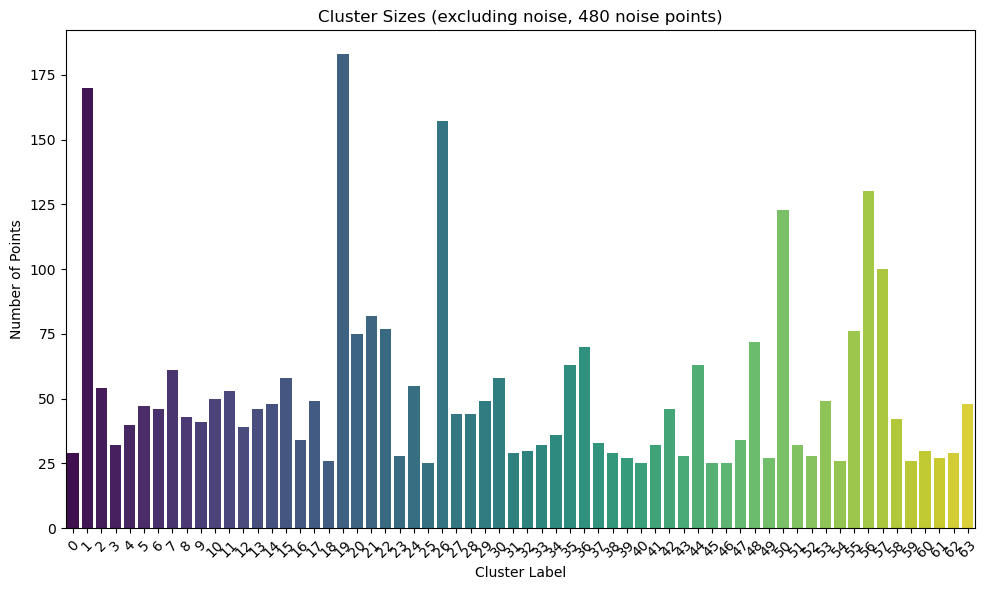

In [218]:
# Visualize cluster sizes as bar plot


# Get cluster labels
labels = clusterer.labels_

# Convert to a Pandas Series for easier manipulation
label_series = pd.Series(labels, name='Cluster')

# Count occurrences of each label
cluster_counts = label_series.value_counts().sort_index()

# Separate noise points from clusters
noise_count = cluster_counts.get(-1, 0)
cluster_counts_no_noise = cluster_counts[cluster_counts.index != -1]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_counts_no_noise.index, y=cluster_counts_no_noise.values, palette='viridis')

plt.title(f'Cluster Sizes (excluding noise, {noise_count} noise points)')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Points')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# take into account, that cluster = -1 represent outliers (noise points)

Which conclusions you can make even now based on the clusters distribution? 

Based on this code try to find out what are noise points / outliers here? Why can they appear? If the amount of outliers always fixed or can differ? If can differ - what it depends on?

Let's plot result of clustering in 2d...

In [219]:
from sklearn.manifold import MDS
from sklearn.decomposition import PCA

# Run PCA with only 2 components for visualization purposes
pca = PCA(n_components=2)  # Changed from 823 to 2
pca_result = pca.fit_transform(fps_array)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
centers = np.zeros((n_clusters, 2))

for i in range(n_clusters):
    cluster_points = pca_result[labels == i]
    centers[i] = np.mean(cluster_points, axis=0)

# Calculate "cluster centers" for HDBSCAN clusters
# Initialize an array to store cluster centers
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
centers = np.zeros((n_clusters, 2))

# Calculate the mean position of points in each cluster in PCA space
for i in range(n_clusters):
    cluster_points = pca_result[labels == i]
    centers[i] = np.mean(cluster_points, axis=0)

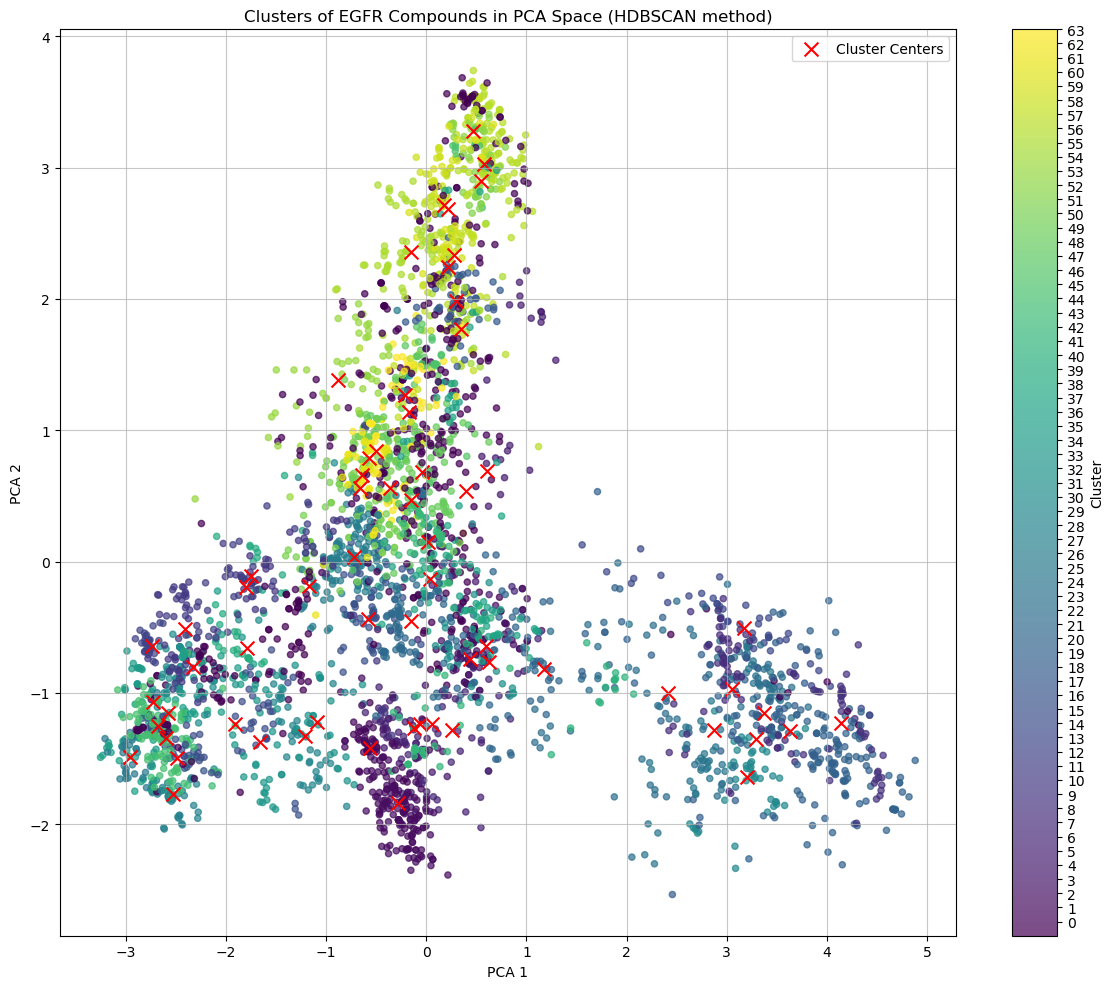

In [220]:
# Create the visualization
plt.figure(figsize=(12, 10))

# Create a colormap that excludes -1 (noise points)
unique_labels = np.unique(labels)
if -1 in unique_labels:
    unique_labels = unique_labels[unique_labels != -1]

# Create the scatter plot
scatter = plt.scatter(
    pca_result[:, 0], 
    pca_result[:, 1], 
    c=labels, 
    cmap='viridis', 
    alpha=0.7,
    s=20  # Point size
)

# Add grid
plt.grid(True, linestyle='-', alpha=0.7)

# Mark the cluster centers
plt.scatter(
    centers[:, 0], 
    centers[:, 1], 
    c='red', 
    marker='x', 
    s=100, 
    label='Cluster Centers'
)

# Add color bar and labels
cbar = plt.colorbar(scatter, label='Cluster')
cbar.set_ticks(np.unique(labels)[np.unique(labels) >= 0])  # Only show actual cluster labels
plt.title('Clusters of EGFR Compounds in PCA Space (HDBSCAN method)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()

# Add tight layout for better spacing
plt.tight_layout()

# Save and show the figure
# plt.savefig('hdbscan_clusters_visualization.png', dpi=300)
plt.show()

...and in 3d:

In [221]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA

def calculate_cluster_centers_3d(pca_result, labels):
    """
    Calculate the center points of each cluster in 3D PCA space.
    
    Parameters:
    -----------
    pca_result : numpy.ndarray
        The PCA transformed data with 3 components
    labels : numpy.ndarray
        Cluster labels for each data point
        
    Returns:
    --------
    numpy.ndarray
        Array of cluster centers, shape (n_clusters, 3)
    """
    # Get number of clusters, excluding noise points (labeled as -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    # Initialize array to store cluster centers
    centers = np.zeros((n_clusters, 3))
    
    # Calculate the mean position of points in each cluster in PCA space
    for i in range(n_clusters):
        cluster_points = pca_result[labels == i]
        centers[i] = np.mean(cluster_points, axis=0)
    
    return centers

def create_3d_cluster_visualization(pca_result, cluster_labels, ligand_df, centers=None):
    """
    Creates an interactive 3D visualization of clusters using Plotly.
    
    Parameters:
    -----------
    pca_result : numpy.ndarray
        The PCA transformed data with 3 components
    cluster_labels : numpy.ndarray
        Cluster labels for each data point
    ligand_df : pandas.DataFrame
        DataFrame containing ligand information including pIC50 values
    centers : numpy.ndarray, optional
        Cluster centers in PCA space
        
    Returns:
    --------
    plotly.graph_objects.Figure
        The interactive 3D plot figure
    """
    print("Creating interactive 3D visualization with Plotly")
    
    # Create a DataFrame for easy plotting with Plotly
    plot_df = pd.DataFrame({
        'PCA1': pca_result[:, 0],
        'PCA2': pca_result[:, 1],
        'PCA3': pca_result[:, 2],
        'Cluster': cluster_labels.astype(str),  # Convert to string for discrete color mapping
    })
    
    # Start with an empty figure with a 3D scene
    fig = make_subplots(rows=1, cols=1, specs=[[{'type': 'scatter3d'}]])
    
    # Get a colormap that matches the 'viridis' used in matplotlib
    # This ensures consistency between 2D and 3D plots
    cluster_ids = sorted(plot_df['Cluster'].unique())
    n_clusters = len(cluster_ids)
    colorscale = px.colors.sequential.Viridis
    colors = [colorscale[int(i * len(colorscale) / n_clusters)] for i in range(n_clusters)]
    
    # Create color mapping dictionary
    color_map = dict(zip(cluster_ids, colors))
    
    # Add data points cluster by cluster to ensure correct coloring
    for cluster_id in cluster_ids:
        cluster_data = plot_df[plot_df['Cluster'] == cluster_id]
        
        fig.add_trace(go.Scatter3d(
            x=cluster_data['PCA1'],
            y=cluster_data['PCA2'],
            z=cluster_data['PCA3'],
            mode='markers',
            marker=dict(
                size=3,  # Smaller point size makes visualization less cluttered
                color=color_map[cluster_id],
                opacity=0.7,
                symbol='circle'
            ),
            name=f'Cluster {cluster_id}',
            hovertemplate='<b>Cluster:</b> %{text}<br>'
                          '<b>PCA1:</b> %{x:.4f}<br>'
                          '<b>PCA2:</b> %{y:.4f}<br>'
                          '<b>PCA3:</b> %{z:.4f}<br>',

            text=[cluster_id] * len(cluster_data),
        ))
    
    # Add cluster centers if provided
    if centers is not None:
        for i in range(len(centers)):
            fig.add_trace(go.Scatter3d(
                x=[centers[i, 0]],
                y=[centers[i, 1]],
                z=[centers[i, 2]],
                mode='markers',
                marker=dict(
                    color='red',
                    size=15,  # Larger size for visibility
                    symbol='cross',  # This gives you the "+" shape
                    line=dict(width=2, color='black')  # Add outline for better visibility
                ),
                name=f'Center {i}',
                hoverinfo='name'
            ))
    
    # Update layout for better visualization
    fig.update_layout(
        title='Interactive 3D Visualization of EGFR Compound Clusters',
        scene=dict(
            xaxis_title='Principal Component 1',
            yaxis_title='Principal Component 2',
            zaxis_title='Principal Component 3',
            # Adding more grid lines for better spatial perception
            xaxis=dict(showgrid=True, gridwidth=1, gridcolor='lightgray'),
            yaxis=dict(showgrid=True, gridwidth=1, gridcolor='lightgray'),
            zaxis=dict(showgrid=True, gridwidth=1, gridcolor='lightgray'),
        ),
        width=1000,
        height=800,
        legend=dict(
            itemsizing='constant',  # Makes legend items a constant size
            title="Clusters",
            font=dict(size=10)
        ),
        margin=dict(l=0, r=0, t=40, b=0)  # Tight margins for more space
    )
    
    return fig

# Complete example showing how to use the functions
def run_full_analysis(fps_array, ligand_df, cluster_labels):
    """
    Runs the complete analysis pipeline: PCA, cluster center calculation, and 3D visualization.
    
    Parameters:
    -----------
    fps_array : numpy.ndarray
        Array of molecular fingerprints or other high-dimensional data
    ligand_df : pandas.DataFrame
        DataFrame containing ligand information including pIC50 values
    cluster_labels : numpy.ndarray
        Cluster labels for each data point
        
    Returns:
    --------
    plotly.graph_objects.Figure
        The interactive 3D plot figure
    """
    # Run PCA with 3 components
    pca = PCA(n_components=3)
    pca_result = pca.fit_transform(fps_array)
    
    # Calculate cluster centers
    centers = calculate_cluster_centers_3d(pca_result, cluster_labels)
    
    # Create and return the 3D visualization
    fig = create_3d_cluster_visualization(pca_result, cluster_labels, ligand_df, centers)
    
    # Save the interactive visualization as HTML
    fig.write_html('umap_hdbscan_interactive_3d_clusters.html')
    
    return fig

# Example usage
fig = run_full_analysis(fps_array, ligand_df, labels)
fig.show()  # Display the interactive plot

Creating interactive 3D visualization with Plotly


DBCV score for performed clustering.

In [222]:
import dbcv


# Calculate dbcv score
dbcv_score = dbcv.dbcv(umap_embedding,clusterer.labels_)

### silhouette score
sil_score = silhouette_score(umap_embedding,clusterer.labels_)

print("DBCV Score:", dbcv_score)
print("Sil Score:", sil_score)


DBCV Score: 0.6407125994352949
Sil Score: 0.44069633


As you can see, Silhouette score is quite low in comparison to Dbcv score. Why? Which score is better to use for evaluating density-based clustering results and why?

Let's check in which cluster our ligand molecule (AFATINIB) were added and which other molecules can be found with it. 

Let's find it by it's CHEMBL ID that we found on prev step (during Virtual screening using similarity search). 

In [223]:
# Find which cluster contains our ligand molecule with known activity

target_molecule_id = "CHEMBL1422"

ligand_df_dbscan["cluster"] = clusterer.labels_

target_molecule= ligand_df_dbscan[ligand_df_dbscan["molecule_chembl_id"] == target_molecule_id]

# Check if the target molecule exists

if not target_molecule.empty:
    # Retreve Cluster
    cluster = target_molecule["cluster"].values[0]
    print(f"The molecule {target_molecule_id} is in cluster {cluster}.")
else:
    print(f"Molecule {target_molecule_id} not found in the dataset.")

The molecule CHEMBL1422 is in cluster 35.


In [224]:
# Count how many molecules are in this cluster
cluster_members = ligand_df_dbscan[ligand_df_dbscan["cluster"]==cluster]
cluster_size = len(cluster_members)

print(cluster_size)

63


In [225]:
# Show 15-30 molecules from same cluster as grid image so you can compare them with AFATINIB. Make conclusion on their similarity 
sample_size = 20
sampled_cluster_df = cluster_members.sample(n=sample_size)

view = mols2grid.display(
        sampled_cluster_df,
        mol_col="Mol",
        subset=["cluster","img"],
        tooltip=["molecule_chembl_id","cluster","pIC50"],
        n_cols=5,
        useSVG=True
    )
display(view)

In [226]:
# Create a basic visualization of entire cluster with mols2grid (like in examples above)

view = mols2grid.display(
    cluster_members,
    mol_col = "Mol",
    subset=["cluster","img"],
    tooltip=["molecule_chembl_id","cluster","pIC50"],
    size=(150,150),
    n_cols=5,
    useSVG=True
)
display(view)


Make conclusion about similarity of the molecules (by structure) that we got within one cluster using density-based method in comparison to Kmean.

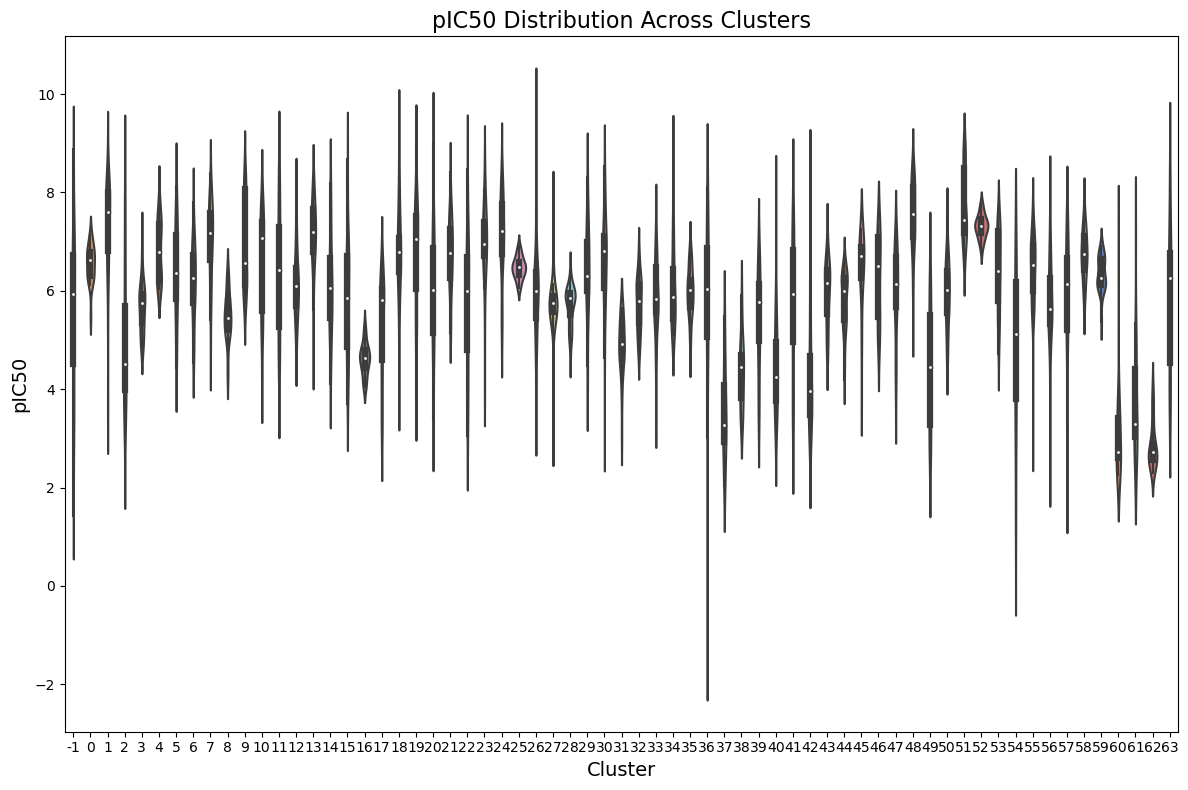

Promising Clusters Based on pIC50 Median:
cluster
0     6.619789
1     7.593543
4     6.784318
5     6.366532
6     6.268277
7     7.180456
9     6.568636
10    7.071334
11    6.431798
12    6.096910
13    7.188375
18    6.782612
19    7.045757
21    6.769551
23    6.943028
24    7.221849
25    6.478208
29    6.292430
30    6.808452
43    6.150096
45    6.698970
46    6.508638
47    6.139672
48    7.553119
51    7.432434
52    7.314281
53    6.397940
55    6.515759
57    6.136718
58    6.744727
59    6.259709
63    6.252436
Name: pIC50, dtype: float64


In [228]:
# plot pIC50 graph (same as for K-mean) to see pIC50 distribution within each cluster. 
# Find based on that clusters that are more promissing. Explain why do you think so.


# Plot pIC50 distribution for each cluster using a violin plot
plt.figure(figsize=(12, 8))
sns.violinplot(x="cluster", y="pIC50", data=ligand_df_dbscan, palette="muted")

# Title and labels
plt.title("pIC50 Distribution Across Clusters", fontsize=16)
plt.xlabel("Cluster", fontsize=14)
plt.ylabel("pIC50", fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()

# Now, identify promising clusters:
# Look for clusters with higher median pIC50 values (indicating stronger activity)
promising_clusters = ligand_df_dbscan.groupby('cluster')['pIC50'].median()
promising_clusters = promising_clusters[promising_clusters > promising_clusters.median()]  # Threshold above the median

print("Promising Clusters Based on pIC50 Median:")
print(promising_clusters)



You can try clustering with other `min_cluster_size` and `min_samples` depending on your research goals. For selecting proper combination of them you can try **grid analysis**.

Please be carefull with selecting `min_cluster_size` and `min_samples`. Select them based on your research goals considering domain knowledges. Same with selecting params for UMAP before clustering.

In the code below you can see example how grid analysis is normally performed:

In [229]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan
import itertools
from tqdm.notebook import tqdm  # For progress tracking
import dbcv

# Define parameter ranges for grid search
min_cluster_sizes = range(25, 30, 1)
min_samples_values = range(5, 10, 1)

print("min_cluster_sizes", list(min_cluster_sizes))
print("min_samples_values", list(min_samples_values))

# We'll keep cluster_selection_epsilon constant for this initial grid search
# You can run additional searches with different epsilons if needed
cluster_selection_epsilon = 0.1

# Create storage for results
results = []

# Total number of combinations to process
total_combinations = len(min_cluster_sizes) * len(min_samples_values)
print(f"Running grid search with {total_combinations} parameter combinations...")

# Run grid search
for min_cluster_size, min_samples in tqdm(itertools.product(min_cluster_sizes, min_samples_values), 
                                          total=total_combinations):
    # Create HDBSCAN with current parameter combination
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_epsilon=cluster_selection_epsilon,
        metric='euclidean',
        cluster_selection_method='eom'
    )
    
    # Fit the model
    clusterer.fit(umap_embedding)
    
    # Analyze results
    labels = clusterer.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_points = list(labels).count(-1)
    noise_percentage = noise_points / len(labels) * 100

    # Calculate DBCV score (if there are at least 2 clusters)
    dbcv_score = np.nan
    if n_clusters >= 2:
        try:
            # Note: DBCV requires the original distance matrix and cluster labels
            dbcv_score = dbcv.dbcv(umap_embedding, labels, noise_id=-1)
        except Exception as e:
            print(f"Error calculating DBCV for parameters {min_cluster_size}, {min_samples}: {e}")
    
    
    # Store results
    results.append({
        'min_cluster_size': min_cluster_size,
        'min_samples': min_samples,
        'n_clusters': n_clusters,
        'noise_points': noise_points,
        'noise_percentage': noise_percentage,
        'dbcv_score': dbcv_score
    })

# Convert results to DataFrame for easier analysis
results_df = pd.DataFrame(results)

# Print parameter combinations that meet our criteria
print("\nParameter combinations that shows best DBCV sscore:")
best_score_results = results_df.sort_values('dbcv_score', ascending=False).head(20)
best_score_results

min_cluster_sizes [25, 26, 27, 28, 29]
min_samples_values [5, 6, 7, 8, 9]
Running grid search with 25 parameter combinations...


  0%|          | 0/25 [00:00<?, ?it/s]


Parameter combinations that shows best DBCV sscore:


,min_cluster_size,min_samples,n_clusters,noise_points,noise_percentage,dbcv_score
2,25,7,64,480,12.581913,0.640713
4,25,9,63,519,13.604194,0.632898
3,25,8,64,529,13.866317,0.632111
0,25,5,63,486,12.739187,0.618811
7,26,7,60,580,15.203145,0.617322
1,25,6,65,510,13.368283,0.615310
24,29,9,49,515,13.499345,0.615250
17,28,7,53,597,15.648755,0.615007
9,26,9,58,586,15.360419,0.612519
22,29,7,49,515,13.499345,0.611956


Find based on received score(s) best possible combination of params and try to cluster using them.

Analyse received results.

Make conclusions based on them.

----

**Tasks**:

From here on, there's a variety of tasks you could follow the clustering up with. A few suggestions:
- Calculate the maximum common substructure of your clusters    
(check out e.g. https://github.com/volkamerlab/teachopencadd/blob/master/teachopencadd/talktorials/T006_compound_maximum_common_substructures/talktorial.ipynb)
- Test out other clustering algorithms or settings. For an overview of clustering algorithms included in scikit-learn, see https://scikit-learn.org/stable/modules/clustering.html
- Similarly, there are many different ways to encode your ligands - check out other fingerprints (or play around with the settings of the Morgan fingerprint).   

One could also describe their ligands in terms of a set of calculated properties (1D descriptors). 

However, what might be problems there (think of scaling)?

- Try to calculate and visualize average properties of your clusters. Do they differ?